<img src="mioti.png" style="height: 100px">
<center style="color:#888">Data Science with Python</center>

#  **Ranking de exoplanetas potencialmente habitables** - V.1

### **Objetivo del trabajo**

El objetivo de este Trabajo Fin de Máster es desarrollar un enfoque reproducible y físicamente interpretable para identificar y priorizar exoplanetas potencialmente habitables a partir de datos observacionales, mediante la construcción de un índice de similitud con la Tierra basado en variables físicas.

Por la naturaleza del proyecto, el propósito no es entrenar modelos predictivos, sino definir un criterio cuantitativo de similitud planetaria que permita ordenar los exoplanetas según su cercanía al estado terrestre, proporcionando así un ranking objetivo dentro del conjunto disponible.

### **Enfoque metodológico**

El trabajo se estructura como un proceso completo de análisis de datos y construcción de un índice, compuesto por las siguientes fases:

**Preparación del dataset**

* Selección justificada de variables físicas relevantes.
* Tratamiento de valores nulos mediante imputación.
* Identificación y tratamiento de valores extremos.
* Construcción del dataset final de trabajo.

**Análisis exploratorio y descriptivo**

* Exploración inicial de distribuciones.
* Detección y tratamiento de outliers.
* Caracterización estadística del dataset final.
* Análisis de correlaciones entre variables.

**Construcción del índice de habitabilidad**

* Definición formal del índice como distancia al vector Tierra.
* Construcción del vector de referencia terrestre.
* Escalado relativo de variables (basado en percentiles).
* Cálculo de desviaciones por variable.
* Agregación de desviaciones.
* Obtención del índice final de habitabilidad.

**Resultados y validación**

* Generación del ranking de exoplanetas.
* Interpretación del top de candidatos.
* Validación exploratoria mediante visualizaciones.
* Análisis de sensibilidad para evaluar la estabilidad del ranking.

**Conclusiones.**

### **Decisiones clave del proyecto**

Este trabajo adopta deliberadamente un enfoque físico–geométrico y evita técnicas de modelado predictivo. En particular:

* No se emplean modelos supervisados, ya que no existe una variable objetivo real que represente “habitabilidad” verificable.
* No se aplican métodos de clustering ni aprendizaje no supervisado, dado que el objetivo no es descubrir grupos latentes sino medir similitud explícita con un estado de referencia conocido (la Tierra).
* No se realiza reducción de dimensionalidad matemática (como PCA), ya que se prioriza la interpretabilidad física de cada variable. Las dimensiones se seleccionan explícitamente en función de su significado astrofísico, agrupadas en familias conceptuales
* No se introducen ponderaciones arbitrarias entre variables. Todas las dimensiones físicas contribuyen de forma equivalente al cálculo del índice, evitando subjetividad en la asignación de pesos.
* No se aplica una normalización estadística clásica (por ejemplo, Z-score o StandardScaler), ya que el objetivo no es entrenar un modelo predictivo, sino cuantificar la similitud física de cada exoplaneta respecto a la Tierra. Este tipo de normalización centraría las variables alrededor de la media del conjunto de datos, perdiendo el significado físico del valor terrestre como referencia.

En su lugar, se adopta un escalado relativo basado en percentiles y desviaciones respecto al vector Tierra, lo que permite conservar la interpretación física de cada variable y expresar directamente cuánto se aleja cada planeta de las condiciones terrestres en cada dimensión.

El índice resultante se basa exclusivamente en la distancia conjunta al vector Tierra, proporcionando un criterio objetivo, reproducible y físicamente interpretable.

## 1. Carga de Dataset

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carga el archivo CSV
df_nasa = pd.read_csv("exoplanetas_nasa.csv")
df_nasa.shape


(6028, 683)

In [48]:
df_nasa.head(3)

,objectid,pl_name,pl_letter,hostid,hostname,hd_name,hip_name,tic_id,disc_pubdate,disc_year,...,cb_flag,pl_angsep,pl_angseperr1,pl_angseperr2,pl_angseplim,pl_angsepformat,pl_angsepstr,pl_angsepsymerr,pl_angsep_reflink,pl_ndispec
0,3.10209,K2-178 b,b,2.146336,K2-178,NaN,NaN,TIC 26078330,2018-03,2018,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,3.19225,HD 74698 c,c,2.578884,HD 74698,HD 74698,HIP 42532,TIC 308087983,2023-06,2023,...,0,86.400,NaN,NaN,0.0,NaN,86.400,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,0
2,3.12241,KMT-2016-BLG-1397L b,b,2.103944,KMT-2016-BLG-1397L,NaN,NaN,NaN,2018-11,2018,...,0,0.773,NaN,NaN,0.0,NaN,0.773,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,0


## 2. Reducción del dataset a variables físicas clave

El dataset original del NASA Exoplanet Archive contiene miles de columnas de naturaleza muy heterogénea (identificadores, parámetros físicos, orbitales, propiedades estelares, errores, flags y metadatos). Tal y como se desarrolla en la memoria, antes de cualquier análisis cuantitativo es necesario transformar este catálogo científico en un conjunto reducido de variables interpretable y alineado con el objetivo del trabajo.

En este punto tal como se comento en la introducción, no se aplica una reducción de dimensionalidad matemática (por ejemplo PCA), ya que este tipo de técnicas generan combinaciones abstractas de variables que dificultan la interpretación física de los resultados. Dado que el objetivo final es construir un índice de habitabilidad explicable donde pueda razonarse qué magnitudes influyen en el ranking, se prioriza una selección explícita de variables frente a transformaciones que pueden ser artificiales y distorsionar los resultados.

La estrategia adoptada consiste en una **selección justificada de columnas**, apoyada en la clasificación previa por familias y en criterios físicos y metodológicos: relevancia directa para habitabilidad, cobertura de datos, eliminación de redundancias y preservación de interpretabilidad. De este modo, el análisis se centra en tres familias principales: `variables de identificación` de cada palaneta, `parámetros orbitales (C)`, `propiedades físicas del planeta (D)` y `características de la estrella anfitriona (E)`, descartando el resto como ruido, metadatos o información auxiliar.

Este proceso reduce el catálogo a un subconjunto manejable de variables que representan el sistema planeta–estrella de forma coherente, reproducible y preparando el dataset para las etapas posteriores de imputación, análisis exploratorio y construcción del índice de habitabilidad.


**VARIABLES DE IDENTIFICACION**
* `objectid`: ID numérico interno NASA 
* `pl_name`: nombre completo del planeta
* `hostname`: nombre de la estrella anfitriona

**PROPIEDADES DE LA ÓRBITA**
* `pl_orbper`: periodo orbital del planeta (en días) - Cuántos días tarda el planeta en dar una vuelta completa a su estrella
* `pl_orbsmax`: Distancia media a su estrella (semieje mayor) - A qué distancia está el planeta de su estrella.
* `pl_orbeccen`: Excentricidad orbital - Qué tan circular o alargada es la órbita (alta excentricidad = clima muy extremo)

**PROPIEDADES DEL PLANETA**
* `pl_rade`: Radio del planeta (tamaño)
* `pl_bmasse`: Masa del planeta
* `pl_dens`: Densidad del planeta
* `pl_eqt`: Temperatura de equilibrio 
* `pl_insol`: Radiación recibida

**VFAMILIA E — PROPIEDADES DE LA ESTRELLA**
* `st_teff`: Temperatura superficial de la estrella - Qué caliente es la estrella (Más caliente = más radiación agresiva)
* `st_lum`: Luminosidad de la estrella - Cuánta luz emite la estrella en total (No es temperatura — es potencia)
* `st_mass`: Masa de la estrella - Qué grande es el Sol del planeta (Importa para estabilidad: Estrellas pequeñas viven millones de años.)
* `st_rad`: Radio de la estrella - Tamaño físico de la estrella (Sol grande → zona habitable más lejos)
* `st_met`: Metallicidad - Cuántos elementos “pesados” tiene la estrella (Baja metallicidad → difícil crear planetas tipo Tierra)
* `st_logg`: Gravedad superficial de la estrella - Qué tan “compacta” es la estrella (estrella normal - gigante roja)
* `st_age`: Cuántos miles de millones de años tiene - Edad de la estrella (Cuántos miles de millones de años tiene: estrellas jóvenes son violentas)

In [49]:
num_cols = [
    
     # Familia C - Órbita
    "pl_orbper",
    "pl_orbsmax",
    "pl_orbeccen",

    # Familia D - Planeta
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_eqt",
    "pl_insol",

    # Familia E - Estrella
    "st_teff",
    "st_lum",
    "st_mass",
    "st_rad",
    "st_met",
    "st_logg",
    "st_age"
]

# Columnas de identificación 
id_cols = ["objectid", "pl_name", "hostname"]

# Creamos un nuevo DataFrame con IDs + variables físicas
df_reduced = df_nasa[id_cols + num_cols].copy()

df_reduced["objectid"] = df_reduced["objectid"].astype(str) # para evitar que objectid (float) entre en análisis numérico (corr/describe/etc.)

df_reduced.head()
df_reduced.shape


(6028, 18)

In [50]:
df_reduced.to_csv("exoplanets_reduced_vars.csv", index=False)
df_reduced.head(10)

,objectid,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
0,3.10209,K2-178 b,K2-178,8.747818,NaN,NaN,3.557910,12.40000,1.510,840.29,117.826,5525.00,-0.28382,0.95109,0.887267,0.0900,4.55000,NaN
1,3.19225,HD 74698 c,HD 74698,3449.000000,4.50000,0.200,14.000000,126.00000,0.252,NaN,0.088,5783.00,0.25285,1.03900,1.333000,0.0700,4.12000,7.847
2,3.12241,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,NaN,5.10000,NaN,12.700000,2200.00000,5.900,NaN,NaN,NaN,NaN,0.45000,NaN,NaN,NaN,NaN
3,3.12499,GJ 1061 b,GJ 1061,3.204000,0.02100,0.310,1.100000,1.37000,5.660,NaN,3.800,2953.00,-2.76955,0.12000,0.156000,-0.0800,5.15856,7.000
4,3.2527,Kepler-102 b,Kepler-102,5.286965,0.05521,0.100,0.460000,1.10000,62.000,857.00,90.000,4909.00,-0.58436,0.80300,0.724000,0.1100,4.60000,1.100
5,3.4873,Kepler-1446 b,Kepler-1446,0.689968,0.01405,0.000,0.820000,0.47700,4.750,1539.00,1213.333,4865.00,-0.65135,0.81000,0.750000,0.1100,4.60000,2.630
6,3.11632,HD 13908 b,HD 13908,19.382000,0.15400,0.020,13.900000,274.91000,0.562,NaN,NaN,6255.00,0.60200,1.29000,1.670000,0.0100,4.11000,2.900
7,3.1432,HIP 9618 b,HIP 9618,20.772858,0.14500,0.000,3.828381,8.30000,0.810,640.88,40.300,5649.00,-0.07160,0.94200,0.959300,-0.0180,4.44500,5.600
8,3.12288,HD 202696 c,HD 202696,946.600000,2.34200,0.028,NaN,592.43512,NaN,NaN,NaN,5040.00,1.36922,1.91000,6.430000,0.0200,3.11000,1.320
9,3.5818,Kepler-1697 b,Kepler-1697,33.496900,0.20080,0.000,1.259548,2.12000,5.830,630.00,37.300,4681.53,-0.58813,0.74700,0.772344,0.0341,4.53577,NaN


In [51]:
df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6028 entries, 0 to 6027
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   objectid     6028 non-null   object 
 1   pl_name      6028 non-null   object 
 2   hostname     6028 non-null   object 
 3   pl_orbper    5720 non-null   float64
 4   pl_orbsmax   5726 non-null   float64
 5   pl_orbeccen  5142 non-null   float64
 6   pl_rade      6004 non-null   float64
 7   pl_bmasse    5997 non-null   float64
 8   pl_dens      5920 non-null   float64
 9   pl_eqt       4506 non-null   float64
 10  pl_insol     4240 non-null   float64
 11  st_teff      5759 non-null   float64
 12  st_lum       5743 non-null   float64
 13  st_mass      6021 non-null   float64
 14  st_rad       5737 non-null   float64
 15  st_met       5505 non-null   float64
 16  st_logg      5732 non-null   float64
 17  st_age       4757 non-null   float64
dtypes: float64(15), object(3)
memory usage: 847.8+ K

In [52]:
 # estadisticos basicos sin tratar NaN ni outliers
df_reduced[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pl_orbper,5720.0,74814.176141,5.317788e+06,0.090706,4.341330,11.087324,39.762740,4.020000e+08
pl_orbsmax,5726.0,15.659613,3.521056e+02,0.004400,0.052300,0.101450,0.300337,1.900000e+04
pl_orbeccen,5142.0,0.078610,1.519684e-01,0.000000,0.000000,0.000000,0.091000,9.500000e-01
pl_rade,6004.0,5.809699,5.345519e+00,0.309800,1.820000,2.830000,11.951596,7.734210e+01
pl_bmasse,5997.0,388.935858,1.111771e+03,0.020000,4.130000,9.100000,182.433506,1.265150e+04
pl_dens,5920.0,4.922865,3.480170e+01,0.005100,1.300000,2.560000,4.600000,2.000000e+03
pl_eqt,4506.0,916.354672,4.651374e+02,34.000000,569.000000,823.000000,1166.750000,4.050000e+03
pl_insol,4240.0,423.569356,1.322632e+03,0.000300,24.047250,99.786000,382.082000,4.490000e+04
st_teff,5759.0,5410.571891,1.753620e+03,415.000000,4917.500000,5554.000000,5902.000000,5.700000e+04
st_lum,5743.0,-0.135212,7.770618e-01,-6.090000,-0.464655,-0.071600,0.313145,3.800000e+00


## 3. Tratamiento de valores NaN: Imputaciones según tipo de variable

En este apartado se tratan los valores faltantes (NaN) de las variables físicas seleccionadas. Dado que el objetivo del trabajo es construir un índice de habitabilidad a partir de magnitudes físicas, no es viable eliminar de forma general los registros con NaN, porque reduciría en exceso la muestra y podría introducir sesgos.

Como primer paso, se cuantifican los NaN por variable para entender el patrón de ausencia (qué variables están peor medidas y en qué magnitud). A partir de ahí, la imputación no se aplica de forma única, sino según el tipo de variable y la naturaleza de la relación física que la rige. Operativamente se distinguen tres tipos de estrategia:

**Tipo A (estadística robusta – mediana)**: para variables donde no existe una relación física directa simple que permita reconstruir el valor faltante con otras columnas disponibles, se utiliza la mediana como estimador robusto. Matemáticamente, la mediana minimiza el error absoluto medio y es menos sensible a colas largas y valores extremos, por lo que es adecuada cuando hay asimetría y outliers.

**Tipo B (supuesto físico simple)**: para variables donde la imputación puede hacerse con una regla física directa o una hipótesis simple y estable, se aplica una reconstrucción determinista.

**Tipo C (condicional por relaciones físicas explícitas)**: para variables vinculadas por ecuaciones conocidas (p. ej., relaciones orbitales/energéticas), se imputan solo cuando faltan y solo si existen las variables necesarias para mantener coherencia dimensional. Además, estas imputaciones se validan comprobando que, cuando existe el valor real, el valor reconstruido queda en el mismo orden de magnitud.

Con este enfoque se busca un equilibrio: maximizar el aprovechamiento del dataset sin inventar información, manteniendo consistencia física y minimizando el impacto de los NaN en los análisis posteriores y en el cálculo del índice.

In [53]:
df_imputed  = df_reduced.copy()

Cuantificamos el numero de NaN de cada variable

In [54]:
df_imputed[num_cols].isna().sum()


pl_orbper       308
pl_orbsmax      302
pl_orbeccen     886
pl_rade          24
pl_bmasse        31
pl_dens         108
pl_eqt         1522
pl_insol       1788
st_teff         269
st_lum          285
st_mass           7
st_rad          291
st_met          523
st_logg         296
st_age         1271
dtype: int64

#### **Imputación Tipo A – Mediana** (variables físicas sin relación determinista directa)

En este grupo entran variables para las que no existe una fórmula clara que permita calcular su valor a partir de otras columnas del dataset.

Por eso, cuando aparecen valores perdidos, se sustituyen por la mediana de cada variable.

Se usa la mediana porque:

* Representa bien un valor “típico”.
* No se ve afectada por valores extremos, que son muy frecuentes en datos astronómicos.
* Evita introducir números artificiales que no tengan sentido físico.

Con esta estrategia simplemente se rellenan los huecos con un valor razonable, manteniendo la escala original de cada variable y sin asumir relaciones que no están demostradas.

Esta estrategia permite completar los NaN manteniendo la estabilidad estadística del conjunto de datos, sin imponer supuestos adicionales sobre relaciones físicas que no están explícitamente modeladas.

In [55]:
cols_type_A = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "st_teff",
    "st_lum",
    "st_mass",
    "st_rad",
    "st_met",
    "st_logg",
    "st_age"
]

for col in cols_type_A:
    median_value = df_imputed[col].median()
    df_imputed[col] = df_imputed[col].fillna(median_value)


#### **Imputación Tipo B – Supuesto físico simple** (excentricidad orbital)

La excentricidad orbital (pl_orbeccen) se imputa asignando valor cero cuando no está disponible, asumiendo órbita circular por defecto.

Esta decisión se basa en que:

* Muchos exoplanetas detectados presentan órbitas aproximadamente circulares, especialmente en sistemas compactos.
* En ausencia de medición directa, asumir excentricidad nula constituye la hipótesis física más conservadora.
* Evita introducir variabilidad artificial en parámetros orbitales que impactan directamente en magnitudes derivadas (temperatura de equilibrio, insolación).
* Permite mantener coherencia dinámica sin sobreinterpretar información inexistente.

En este caso, no usamos mediana porque la excentricidad tiene un valor físico neutro claro: cero. Asumimos órbita circular cuando no hay medida.

Este enfoque prioriza estabilidad del modelo frente a reconstrucciones especulativas cuando no existen datos observacionales suficientes.

In [56]:
# Excentricidad orbital: órbita circular por defecto
df_imputed["pl_orbeccen"] = df_imputed["pl_orbeccen"].fillna(0)


#### **Imputación Tipo C – Reconstrucción condicional mediante relaciones físicas explícitas**

En este grupo se incluyen variables que no admiten una imputación puramente estadística, ya que están gobernadas por relaciones físicas conocidas entre parámetros orbitales y estelares (leyes de Kepler, balance radiativo, dependencia inversa con la distancia, etc.).

Por eso, estos valores solo se reconstruyen cuando:

* El dato original falta.
* Existen todas las variables necesarias para poder calcularlo.

Si alguna de ellas no está disponible, el valor se deja como NaN.

Las variables tratadas en este bloque son:

* Semieje mayor (pl_orbsmax)
* Periodo orbital (pl_orbper)
* Temperatura de equilibrio (pl_eqt)
* Insolación (pl_insol)

Cada una se reconstruye mediante fórmulas físicas simplificadas (ley de Kepler, balance radiativo, relación inversa con la distancia, etc.).

Estas fórmulas no buscan una precisión astrofísica completa: se utilizan como aproximaciones razonables para obtener valores coherentes cuando no hay medidas directas.

El objetivo es mantener consistencia física entre variables, evitando introducir números arbitrarios.


##### **Semieje mayor (pl_orbsmax)** a partir de pl_orbper 

In [57]:
# pl_orbsmax a partir de pl_orbper (Kepler simplificada)
# Idea: para órbitas planetarias, la 3ª ley de Kepler (en unidades astronómicas) relaciona:
#   P^2 ≈ a^3 / M*   ->   a ≈ (P^2 * M*)^(1/3) = P^(2/3) * M*^(1/3)
# donde: P = periodo orbital, a = semieje mayor (distancia media al astro), M* = masa estelar (en masas solares)

# IMPORTANTE (unidades): esta relación se aplica con P en AÑOS y a en AU.
# En el dataset, pl_orbper está en DÍAS, por eso convertimos a años: P_years = P_days / 365.25
# Usamos 365.25 como aproximación estándar del año medio (incluye el efecto de los bisiestos),suficiente para una imputación aproximada


DAYS_PER_YEAR = 365.25

mask_orbsmax = (
    df_imputed["pl_orbsmax"].isna() &
    df_imputed["pl_orbper"].notna() &
    df_imputed["st_mass"].notna()
)

P_years = df_imputed.loc[mask_orbsmax, "pl_orbper"] / DAYS_PER_YEAR

df_imputed.loc[mask_orbsmax, "pl_orbsmax"] = (
    (P_years ** (2/3)) *
    (df_imputed.loc[mask_orbsmax, "st_mass"] ** (1/3))
)


##### **Periodo orbital (pl_orbper)** a partir de pl_orbsmax 

In [58]:
# pl_orbper a partir de pl_orbsmax (Kepler inversa)
# Partimos de la misma forma de la 3ª ley de Kepler:
#   P^2 ≈ a^3 / M*   ->   P ≈ sqrt(a^3 / M*) = a^(3/2) / M*^(1/2)
# Esto nos da P en AÑOS; luego lo convertimos a DÍAS multiplicando por DAYS_PER_YEAR (definido antes).

DAYS_PER_YEAR = 365.25

mask_orbper = (
    df_imputed["pl_orbper"].isna() &
    df_imputed["pl_orbsmax"].notna() &
    df_imputed["st_mass"].notna()
)

P_years = (
    (df_imputed.loc[mask_orbper, "pl_orbsmax"] ** (3/2)) /
    (df_imputed.loc[mask_orbper, "st_mass"] ** (1/2))
)

df_imputed.loc[mask_orbper, "pl_orbper"] = P_years * DAYS_PER_YEAR

##### **Temperatura de equilibrio (pl_eqt)**

Para comprobar que la fórmula usada para estimar la temperatura funciona razonablemente bien, se compara el valor calculado con el valor real en aquellos planetas donde ambos están disponibles.

Esta comprobación sirve simplemente para verificar que el resultado tiene un orden de magnitud coherente (no buscamos precisión exacta).

Cuando pl_eqt no está disponible, la estimamos con una aproximación física sencilla que depende de la temperatura efectiva de la estrella (st_teff), el radio estelar (st_rad) y el semieje mayor orbital (pl_orbsmax).

Un punto clave es la coherencia de unidades: en el dataset, st_rad viene en radios solares y pl_orbsmax en unidades astronómicas (AU). Por eso, antes de aplicar la fórmula convertimos st_rad a AU. Si no se hiciera esta conversión, la fórmula mezclaría unidades y las temperaturas resultantes podrían salir totalmente fuera de rango.

In [59]:
# pl_eqt (temperatura de equilibrio)
# Aproximación simplificada:
#   Teq = T_star * sqrt( R_star / (2*a) )
# IMPORTANTE: R_star y a deben estar en las MISMAS unidades.
# En el dataset: st_rad está en radios solares (R☉) y pl_orbsmax en AU,
# así que convertimos st_rad -> AU antes de aplicar la fórmula.

RSUN_TO_AU = 0.00465047  # 1 R☉ ≈ 0.00465047 AU

mask_eqt = (
    df_imputed["pl_eqt"].isna() &
    df_imputed["st_teff"].notna() &
    df_imputed["st_rad"].notna() &
    df_imputed["pl_orbsmax"].notna()
)

R_star_AU = df_imputed.loc[mask_eqt, "st_rad"] * RSUN_TO_AU

df_imputed.loc[mask_eqt, "pl_eqt"] = (
    df_imputed.loc[mask_eqt, "st_teff"] *
    np.sqrt(R_star_AU / (2 * df_imputed.loc[mask_eqt, "pl_orbsmax"]))
)

##### **Insolación (pl_insol)**

In [60]:
# pl_insol (insolación)
# Relación básica del flujo radiativo:
# S ∝ L / a^2
# donde L es la luminosidad estelar y a el semieje mayor orbital.
# st_lum está en log10(L/Lsun), por lo que se convierte a escala lineal como 10**st_lum.
# Usamos esta relación directa como imputación física aproximada cuando pl_insol es NaN.

mask_insol = (
    df_imputed["pl_insol"].isna() &
    df_imputed["st_lum"].notna() &
    df_imputed["pl_orbsmax"].notna()
)

df_imputed.loc[mask_insol, "pl_insol"] = (
    (10 ** df_imputed.loc[mask_insol, "st_lum"]) /
    (df_imputed.loc[mask_insol, "pl_orbsmax"] ** 2)
)

In [61]:
df_imputed[num_cols].isna().sum()

pl_orbper      7
pl_orbsmax     7
pl_orbeccen    0
pl_rade        0
pl_bmasse      0
pl_dens        0
pl_eqt         7
pl_insol       7
st_teff        0
st_lum         0
st_mass        0
st_rad         0
st_met         0
st_logg        0
st_age         0
dtype: int64

In [62]:
df_imputed.shape

(6028, 18)

#### Identificación de registros con valores faltantes residuales

Tras aplicar las distintas estrategias de imputación, se comprueba si todavía existen registros que presentan valores faltantes en las variables orbitales y energéticas clave. Para ello, se identifican aquellas filas que contienen al menos un valor nulo en el subconjunto de variables directamente relacionadas con la órbita y el entorno energético del planeta (`pl_orbper`, `pl_orbsmax`, `pl_eqt`, `pl_insol`).

Este paso permite aislar los registros problemáticos y cuantificar cuántos planetas no han podido ser completamente imputados debido a la falta simultánea de información mínima. 


In [63]:
# Definimos las columnas problemáticas: variables orbitales y energéticas que son necesarias para caracterizar el sistema planeta–estrella
cols_problem = ["pl_orbper", "pl_orbsmax", "pl_eqt", "pl_insol"]

mask_incomplete = df_imputed[cols_problem].isna().any(axis=1)
print("Registros incompletos:", mask_incomplete.sum())

print(df_imputed.shape)
print(df_imputed[num_cols].isna().sum())


Registros incompletos: 7
(6028, 18)
pl_orbper      7
pl_orbsmax     7
pl_orbeccen    0
pl_rade        0
pl_bmasse      0
pl_dens        0
pl_eqt         7
pl_insol       7
st_teff        0
st_lum         0
st_mass        0
st_rad         0
st_met         0
st_logg        0
st_age         0
dtype: int64


El valor 7 indica que existen 7 registros en el dataset original en los que faltan simultáneamente:

* el periodo orbital (pl_orbper)
* el semieje mayor (pl_orbsmax)

In [64]:
# Vemos que sigue habiendo 6028 registros

df_imputed.shape

(6028, 18)

## 4. Construcción del dataset final de trabajo

Como se ha justificado anteriormente, se decide eliminar estos 7 registros para no tener registros con algun valor NaN. Estos registros se eliminan porque faltan simultáneamente variables orbitales y energéticas, lo que impide reconstruir el sistema planeta–estrella de forma físicamente coherente. Dado que son 7 casos sobre 6028 (≈0,12%) y estas variables son esenciales para el análisis posterior, se eliminan para mantener un dataset final físicamente consistente.

In [65]:
# Eliminación de 7 los registros que todavia tienen NaN
# Columnas que todavía presentan valores nulos residuales
cols_problem = ["pl_orbper", "pl_orbsmax", "pl_eqt", "pl_insol"]

# Creamos el dataframe de trabajo eliminando los registros incompletos
df_work = df_imputed.dropna(subset=cols_problem)

In [66]:
# Comprobación de que no hay regisros con valores NaN en las variables numéricas
print(df_work.shape) 
print(df_work[num_cols].isna().sum())


(6021, 18)
pl_orbper      0
pl_orbsmax     0
pl_orbeccen    0
pl_rade        0
pl_bmasse      0
pl_dens        0
pl_eqt         0
pl_insol       0
st_teff        0
st_lum         0
st_mass        0
st_rad         0
st_met         0
st_logg        0
st_age         0
dtype: int64


Una vez eliminados los registros incompletos, el dataset final (df_work) queda compuesto por 6021 exoplanetas sin valores faltantes en ninguna de las variables consideradas. A partir de este punto se dispone de un conjunto de datos físicamente coherente y completamente definido, listo para las fases posteriores de análisis.

## 5. Exploración inicial de distribuciones y detección de outliers

In [67]:
# Estructura general
df_work.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6021 entries, 0 to 6027
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   objectid     6021 non-null   object 
 1   pl_name      6021 non-null   object 
 2   hostname     6021 non-null   object 
 3   pl_orbper    6021 non-null   float64
 4   pl_orbsmax   6021 non-null   float64
 5   pl_orbeccen  6021 non-null   float64
 6   pl_rade      6021 non-null   float64
 7   pl_bmasse    6021 non-null   float64
 8   pl_dens      6021 non-null   float64
 9   pl_eqt       6021 non-null   float64
 10  pl_insol     6021 non-null   float64
 11  st_teff      6021 non-null   float64
 12  st_lum       6021 non-null   float64
 13  st_mass      6021 non-null   float64
 14  st_rad       6021 non-null   float64
 15  st_met       6021 non-null   float64
 16  st_logg      6021 non-null   float64
 17  st_age       6021 non-null   float64
dtypes: float64(15), object(3)
memory usage: 893.7+ KB


In [68]:
# Primeras filas para inspección visual
df_work.head()

,objectid,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
0,3.10209,K2-178 b,K2-178,8.747818,0.081711,0.00,3.55791,12.40,1.510,840.290000,117.826000,5525.0,-0.28382,0.95109,0.887267,0.09,4.55000,3.980
1,3.19225,HD 74698 c,HD 74698,3449.000000,4.500000,0.20,14.00000,126.00,0.252,151.773321,0.088000,5783.0,0.25285,1.03900,1.333000,0.07,4.12000,7.847
2,3.12241,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,6271.035104,5.100000,0.00,12.70000,2200.00,5.900,115.771234,0.032603,5554.0,-0.07160,0.45000,0.953000,0.02,4.45300,3.980
3,3.12499,GJ 1061 b,GJ 1061,3.204000,0.021000,0.31,1.10000,1.37,5.660,388.105256,3.800000,2953.0,-2.76955,0.12000,0.156000,-0.08,5.15856,7.000
4,3.2527,Kepler-102 b,Kepler-102,5.286965,0.055210,0.10,0.46000,1.10,62.000,857.000000,90.000000,4909.0,-0.58436,0.80300,0.724000,0.11,4.60000,1.100


Para evaluar el impacto del tratamiento de valores ausentes, se comparan las estadísticas descriptivas antes de la imputación (df_reduced) y después de la imputación (df_work) con el objetivo de evaluar cómo afecta este procedimiento a las medidas de centralidad y dispersión del dataset.

In [69]:
# Antes del tratamiento de NaN
df_reduced[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pl_orbper,5720.0,74814.176141,5.317788e+06,0.090706,4.341330,11.087324,39.762740,4.020000e+08
pl_orbsmax,5726.0,15.659613,3.521056e+02,0.004400,0.052300,0.101450,0.300337,1.900000e+04
pl_orbeccen,5142.0,0.078610,1.519684e-01,0.000000,0.000000,0.000000,0.091000,9.500000e-01
pl_rade,6004.0,5.809699,5.345519e+00,0.309800,1.820000,2.830000,11.951596,7.734210e+01
pl_bmasse,5997.0,388.935858,1.111771e+03,0.020000,4.130000,9.100000,182.433506,1.265150e+04
pl_dens,5920.0,4.922865,3.480170e+01,0.005100,1.300000,2.560000,4.600000,2.000000e+03
pl_eqt,4506.0,916.354672,4.651374e+02,34.000000,569.000000,823.000000,1166.750000,4.050000e+03
pl_insol,4240.0,423.569356,1.322632e+03,0.000300,24.047250,99.786000,382.082000,4.490000e+04
st_teff,5759.0,5410.571891,1.753620e+03,415.000000,4917.500000,5554.000000,5902.000000,5.700000e+04
st_lum,5743.0,-0.135212,7.770618e-01,-6.090000,-0.464655,-0.071600,0.313145,3.800000e+00


In [70]:
# Despues del tratamiento de NaN
df_work[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pl_orbper,6021.0,506801.176508,1.493297e+07,9.070629e-02,4.551400,12.309681,56.358501,8.768941e+08
pl_orbsmax,6021.0,14.905010,3.433862e+02,3.856670e-03,0.052000,0.100000,0.286000,1.900000e+04
pl_orbeccen,6021.0,0.067133,1.431533e-01,0.000000e+00,0.000000,0.000000,0.066000,9.500000e-01
pl_rade,6021.0,5.793161,5.337645e+00,3.098000e-01,1.820000,2.830000,11.900000,7.734210e+01
pl_bmasse,6021.0,385.408151,1.106467e+03,2.000000e-02,4.160000,9.100000,179.891780,1.265150e+04
pl_dens,6021.0,4.879719,3.450930e+01,5.100000e-03,1.320000,2.560000,4.540000,2.000000e+03
pl_eqt,6021.0,812.477240,5.229454e+02,1.481161e+00,443.667689,733.000000,1075.000000,7.777781e+03
pl_insol,6021.0,782.286152,1.648455e+04,3.289901e-10,7.130000,57.630734,261.628000,8.782908e+05
st_teff,6021.0,5417.099583,1.715163e+03,4.150000e+02,4952.000000,5554.000000,5885.380000,5.700000e+04
st_lum,6021.0,-0.132183,7.589986e-01,-6.090000e+00,-0.439850,-0.071600,0.297000,3.800000e+00


La comparación entre ambos resúmenes muestra que la imputación no solo completa valores faltantes, sino que también modifica de forma apreciable algunos estadísticos globales. En varias variables, especialmente las orbitales, se observa una reducción marcada de la media y de la desviación típica (por ejemplo en pl_orbper), indicando que antes de la imputación los valores disponibles estaban sesgados hacia observaciones más extremas.

En conjunto, la imputación produce un dataset más equilibrado desde el punto de vista estadístico, reduciendo sesgos en medias y dispersiones y proporcionando una base más representativa para el análisis posterior de valores extremos y correlaciones.

#### Visualizaciones de las variables por familias

In [71]:
vars_c = ['pl_orbper','pl_orbsmax','pl_orbeccen']
vars_d = ['pl_rade','pl_bmasse','pl_dens','pl_eqt','pl_insol']
vars_e = ['st_teff','st_lum','st_mass','st_rad','st_met','st_logg','st_age']

VISUALIZACIÓN FAMILIA C — PROPIEDADES DE LA ÓRBITA

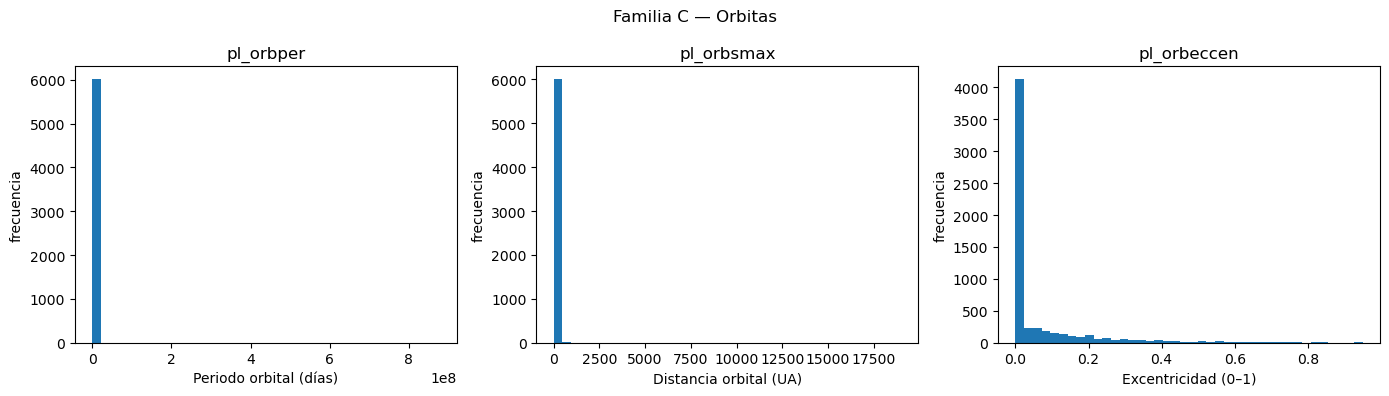

In [72]:
vars_c = ['pl_orbper','pl_orbsmax','pl_orbeccen']

units_c = {
    'pl_orbper': 'Periodo orbital (días)',
    'pl_orbsmax': 'Distancia orbital (UA)',
    'pl_orbeccen': 'Excentricidad (0–1)'
}


# Histogramas
plt.figure(figsize=(14,4))

i = 1
for col in vars_c:
    plt.subplot(1,3,i)
    plt.hist(df_work[col], bins=40)
    plt.title(col)
    plt.xlabel(units_c[col]) 
    plt.ylabel("frecuencia")
    i = i + 1

plt.suptitle("Familia C — Orbitas")
plt.tight_layout()
plt.show()


`pl_orbper (periodo orbital)`

* La distribución muestra una fuerte concentración de planetas con periodos orbitales muy cortos, lo que indica que la mayoría de exoplanetas detectados orbitan muy cerca de su estrella.

`pl_orbsmax (distancia a la estrella)`

* La distancia orbital presenta un comportamiento similar, con una gran acumulación de planetas a distancias pequeñas y algunos casos extremos a distancias muy grandes.

`pl_orbeccen (excentricidad orbital)`

* A diferencia de las anteriores, la excentricidad se distribuye en un rango acotado entre 0 y 1, permitiendo visualizar mejor su forma.

**VISUALIZACIÓN FAMILIA D — PROPIEDADES DEL PLANETA**
* `pl_rade`: Radio del planeta (tamaño)
* `pl_bmasse`: Masa del planeta
* `pl_dens`: Densidad del planeta
* `pl_eqt`: Temperatura de equilibrio 
* `pl_insol`: Radiación recibida

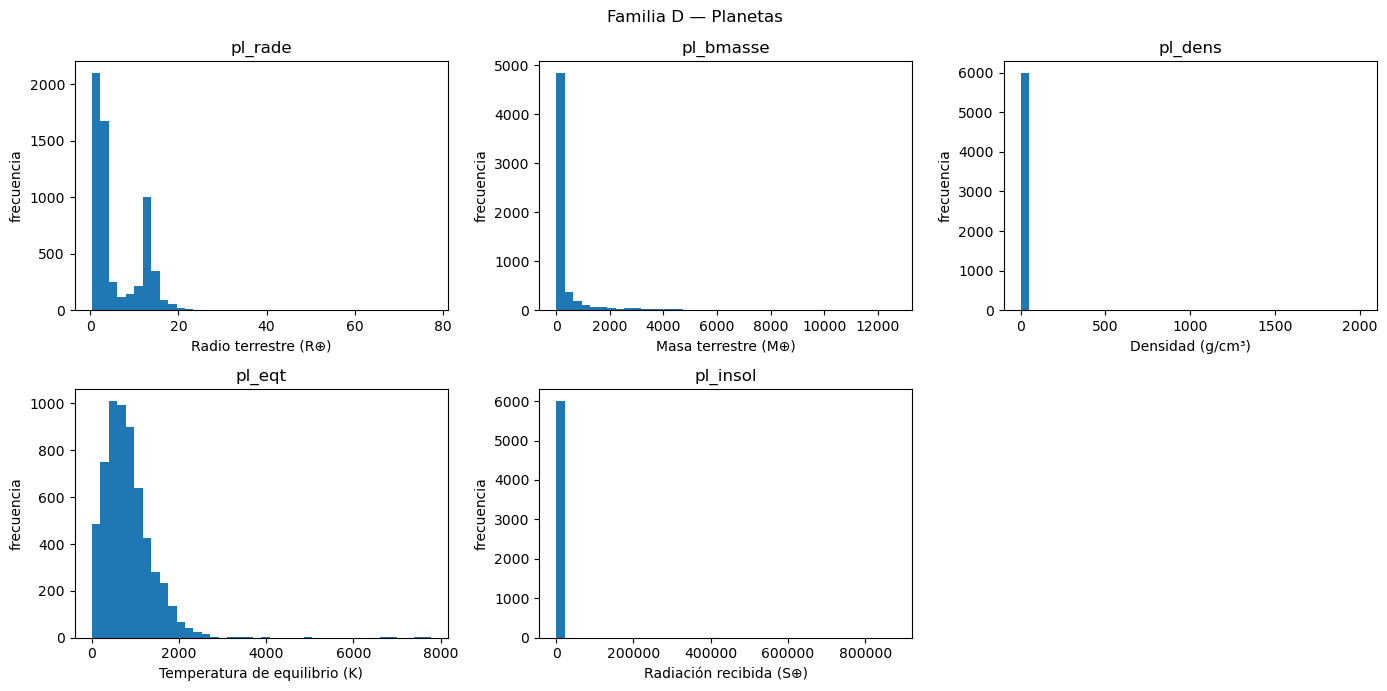

In [73]:
vars_d = ['pl_rade','pl_bmasse','pl_dens','pl_eqt','pl_insol']

units_d = {
    'pl_rade': 'Radio terrestre (R⊕)',
    'pl_bmasse': 'Masa terrestre (M⊕)',
    'pl_dens': 'Densidad (g/cm³)',
    'pl_eqt': 'Temperatura de equilibrio (K)',
    'pl_insol': 'Radiación recibida (S⊕)'
}

# Histogramas
plt.figure(figsize=(14,7))

i = 1
for col in vars_d:
    plt.subplot(2,3,i)
    plt.hist(df_work[col], bins=40)
    plt.title(col)
    plt.xlabel(units_d[col]) 
    plt.ylabel("frecuencia")
    i = i + 1

plt.suptitle("Familia D — Planetas")
plt.tight_layout()
plt.show()

``pl_rade (radio del planeta)``

* La distribución muestra una fuerte concentración de planetas con radios pequeños, lo que indica que la mayoría de exoplanetas detectados tienen tamaños comparables o moderadamente superiores al de la Tierra.

``pl_bmasse (masa del planeta)``

* La mayoría de masas se agrupan en valores bajos, lo que es coherente con un conjunto dominado por planetas pequeños/medios y con la dificultad de detectar planetas muy masivos en todos los rangos.

``pl_dens (densidad del planeta)``

* La densidad muestra una distribución muy concentrada en valores bajos, con la mayoría de planetas agrupados en un rango reducido.

``pl_eqt (temperatura de equilibrio)``

* La distribución se acumula en temperaturas relativamente bajas, mientras que la cola hacia valores altos refleja la abundancia de planetas muy cercanos a su estrella (más calentados).

``pl_insol (radiación recibida)``

* La radiación recibida se concentra cerca de valores bajos/moderados, lo que sugiere que muchos planetas del conjunto no están sometidos a irradiación extrema, aunque el rango sea amplio.



**VISUALIZACIÓN FAMILIA E — PROPIEDADES DE LA ESTRELLA**
* `st_teff`: **Temperatura superficial de la estrella** - Qué caliente es la estrella (Más caliente = más radiación agresiva)
* `st_lum`: **Luminosidad de la estrella** - Cuánta luz emite la estrella en total (No es temperatura — es potencia)
* `st_mass`: **Masa de la estrella** - Qué grande es el Sol del planeta (Importa para estabilidad: Estrellas pequeñas viven millones de años.)
* `st_rad`: **Radio de la estrella** - Tamaño físico de la estrella (Sol grande → zona habitable más lejos)
* `st_met`: **Metallicidad** - Cuántos elementos “pesados” tiene la estrella (Baja metallicidad → difícil crear planetas tipo Tierra)
* `st_logg`: **Gravedad superficial de la estrella** - Qué tan “compacta” es la estrella (estrella normal - gigante roja)
* `st_age`: **Cuántos miles de millones de años tiene** - Edad de la estrella (Cuántos miles de millones de años tiene: estrellas jóvenes son violentas)

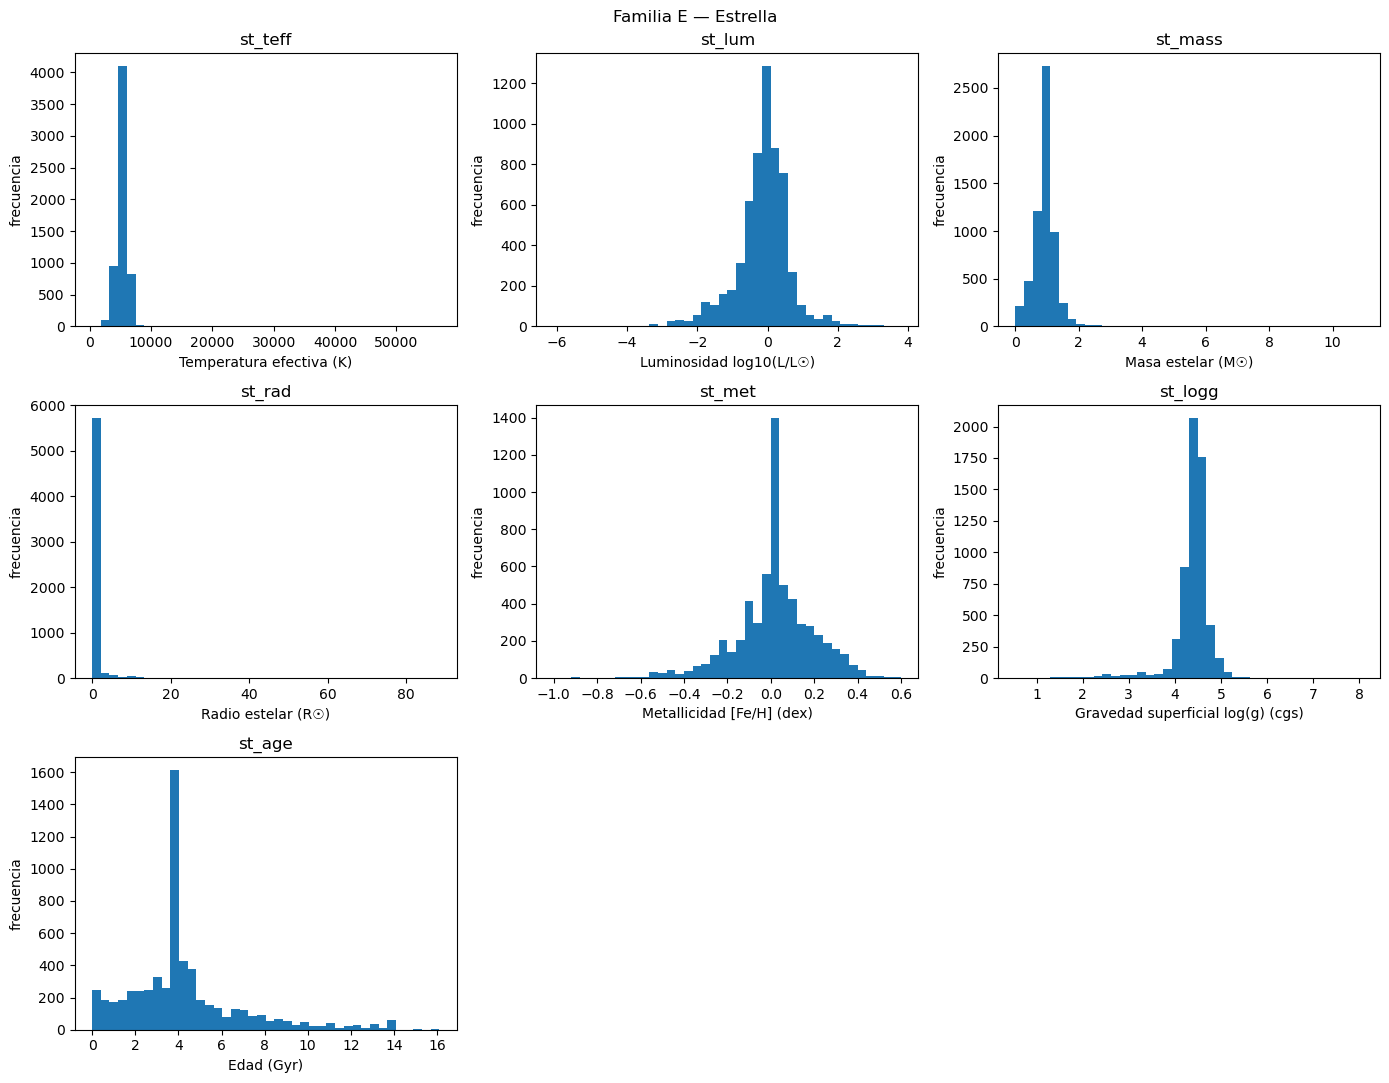

In [74]:
vars_e = ['st_teff','st_lum','st_mass','st_rad','st_met','st_logg','st_age']

units_e = {
    'st_teff': 'Temperatura efectiva (K)',
    'st_lum': 'Luminosidad log10(L/L☉)',
    'st_mass': 'Masa estelar (M☉)',
    'st_rad': 'Radio estelar (R☉)',
    'st_met': 'Metallicidad [Fe/H] (dex)',
    'st_logg': 'Gravedad superficial log(g) (cgs)',
    'st_age': 'Edad (Gyr)'
}


# Histogramas
plt.figure(figsize=(14,11))

i = 1
for col in vars_e:
    plt.subplot(3,3,i)
    plt.hist(df_work[col], bins=40)
    plt.title(col)
    plt.ylabel("frecuencia")
    plt.xlabel(units_e[col]) 
    i = i + 1

plt.suptitle("Familia E — Estrella")
plt.tight_layout()
plt.show()


``st_teff (temperatura efectiva)``

* La distribución se concentra en un rango relativamente estrecho, lo que sugiere que muchas estrellas anfitrionas son “tipo solar” o cercanas a ese perfil térmico.

``st_lum (luminosidad)``

* La distribución se agrupa cerca de valores centrales (en escala logarítmica), indicando que predominan estrellas con luminosidades moderadas, cercanas al orden de magnitud del Sol.

``st_mass (masa estelar)``

* La masa se concentra alrededor de valores cercanos a 1 (en masas solares), lo que es coherente con una mayor presencia de estrellas parecidas al Sol en la muestra.

``st_rad (radio estelar)``

* El radio muestra una fuerte concentración en valores bajos, indicando que muchas estrellas son de tamaño relativamente pequeño o moderado.

``st_met (metallicidad)``

* La metallicidad se concentra alrededor de 0 (similar al Sol), lo que sugiere que muchas estrellas del conjunto tienen composiciones comparables a la solar.

``st_logg (gravedad superficial)``

* La distribución se concentra en valores altos (típicos de estrellas compactas de secuencia principal), lo que apunta a un predominio de estrellas “estables” en el conjunto.

``st_age (edad)``

* La edad muestra una distribución amplia, con concentración en edades intermedias, lo que indica una mezcla de sistemas relativamente jóvenes y maduros.

#### Visualización de Outliers con escala logaritmica

Dado que las variables físicas del dataset presentan rangos muy distintos y colas largas, la representación conjunta mediante boxplots en escala lineal provoca una fuerte compresión del núcleo de las distribuciones, dificultando la identificación visual de valores atípicos.

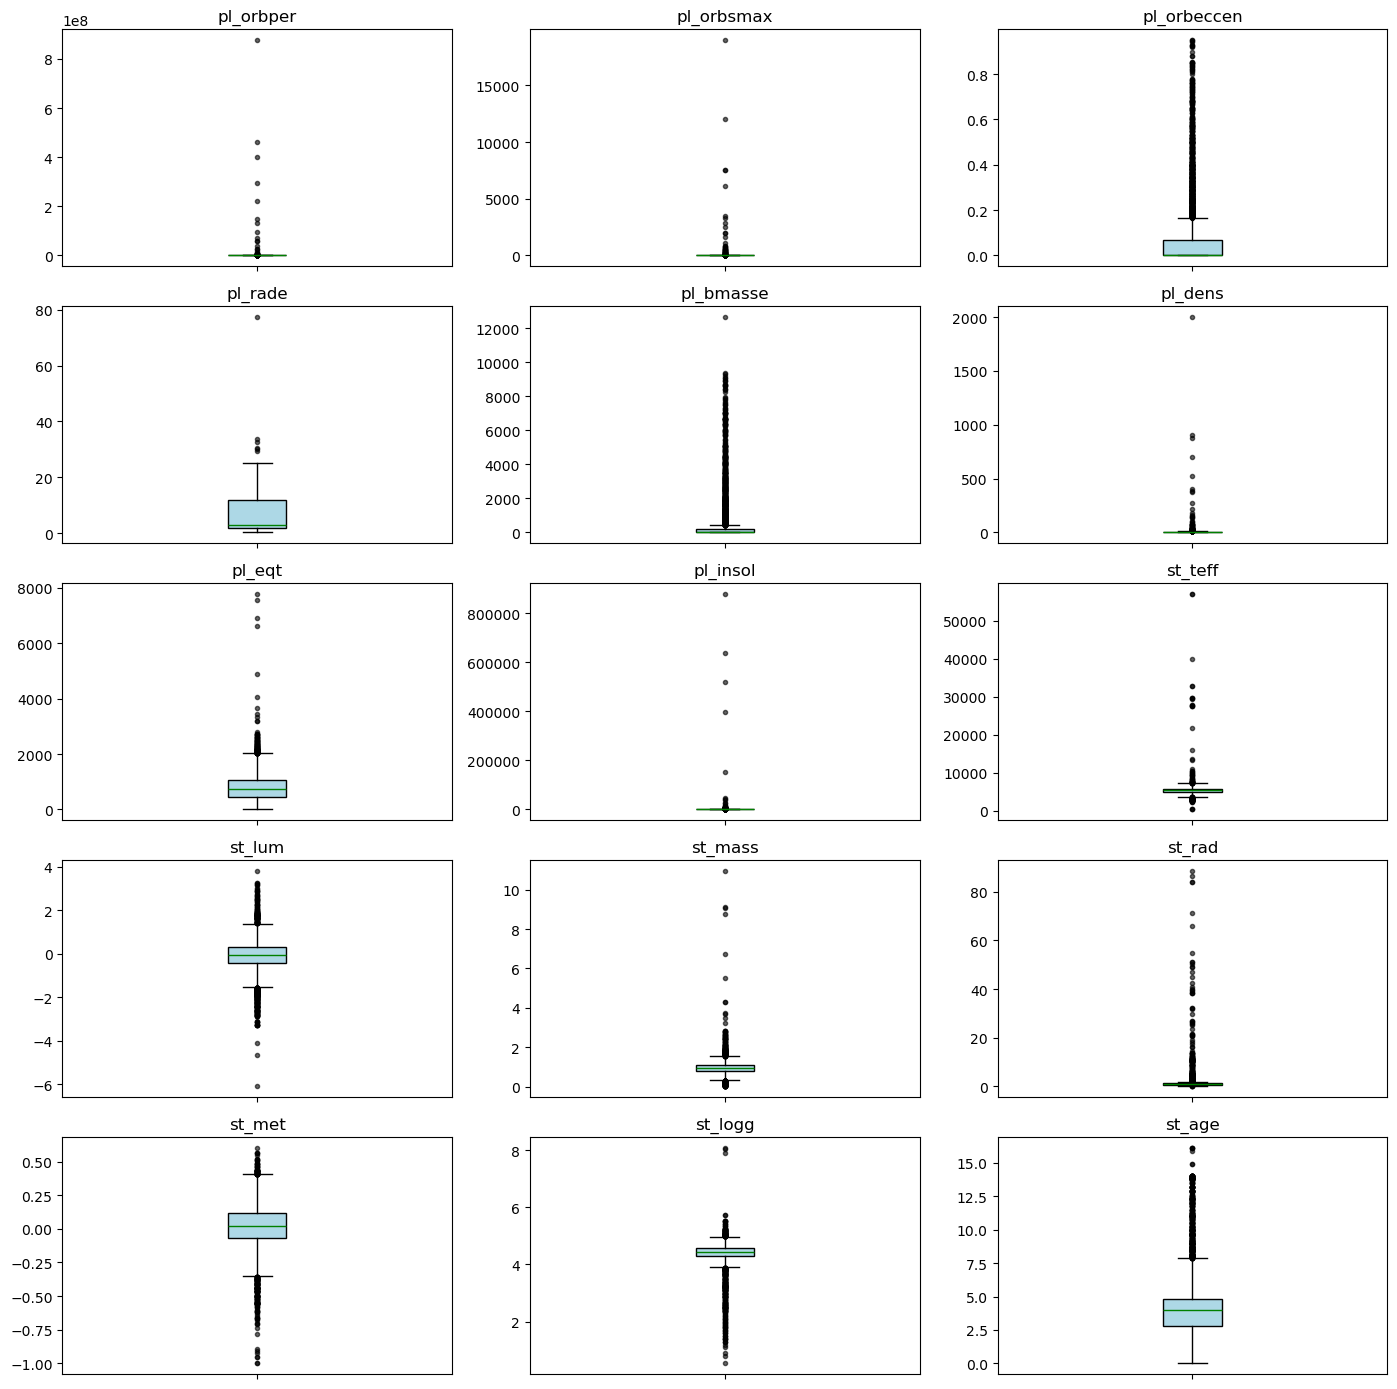

In [75]:
fig, axes = plt.subplots(5, 3, figsize=(14, 14))
axes = axes.flatten()

i = 0

for col in num_cols:
    axes[i].boxplot(
        df_work[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor="lightblue", color="black"),
        medianprops=dict(color="green", linewidth=1),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        flierprops=dict(marker='o', markerfacecolor='black', markersize=3, alpha=0.6)
    )

    axes[i].set_title(col)
    axes[i].tick_params(axis='x', labelbottom=False)
    i = i + 1

plt.tight_layout()
plt.show()


Para mejorar la legibilidad del gráfico, se utiliza una escala logarítmica simétrica (symlog) en el eje vertical. Esta escala combina un comportamiento lineal alrededor del cero con un comportamiento logarítmico para valores de mayor magnitud, permitiendo visualizar simultáneamente la distribución central y los outliers sin que el boxplot quede aplastado.

Este ajuste se emplea exclusivamente con fines de visualización y no altera los datos originales ni el pipeline posterior del análisis.

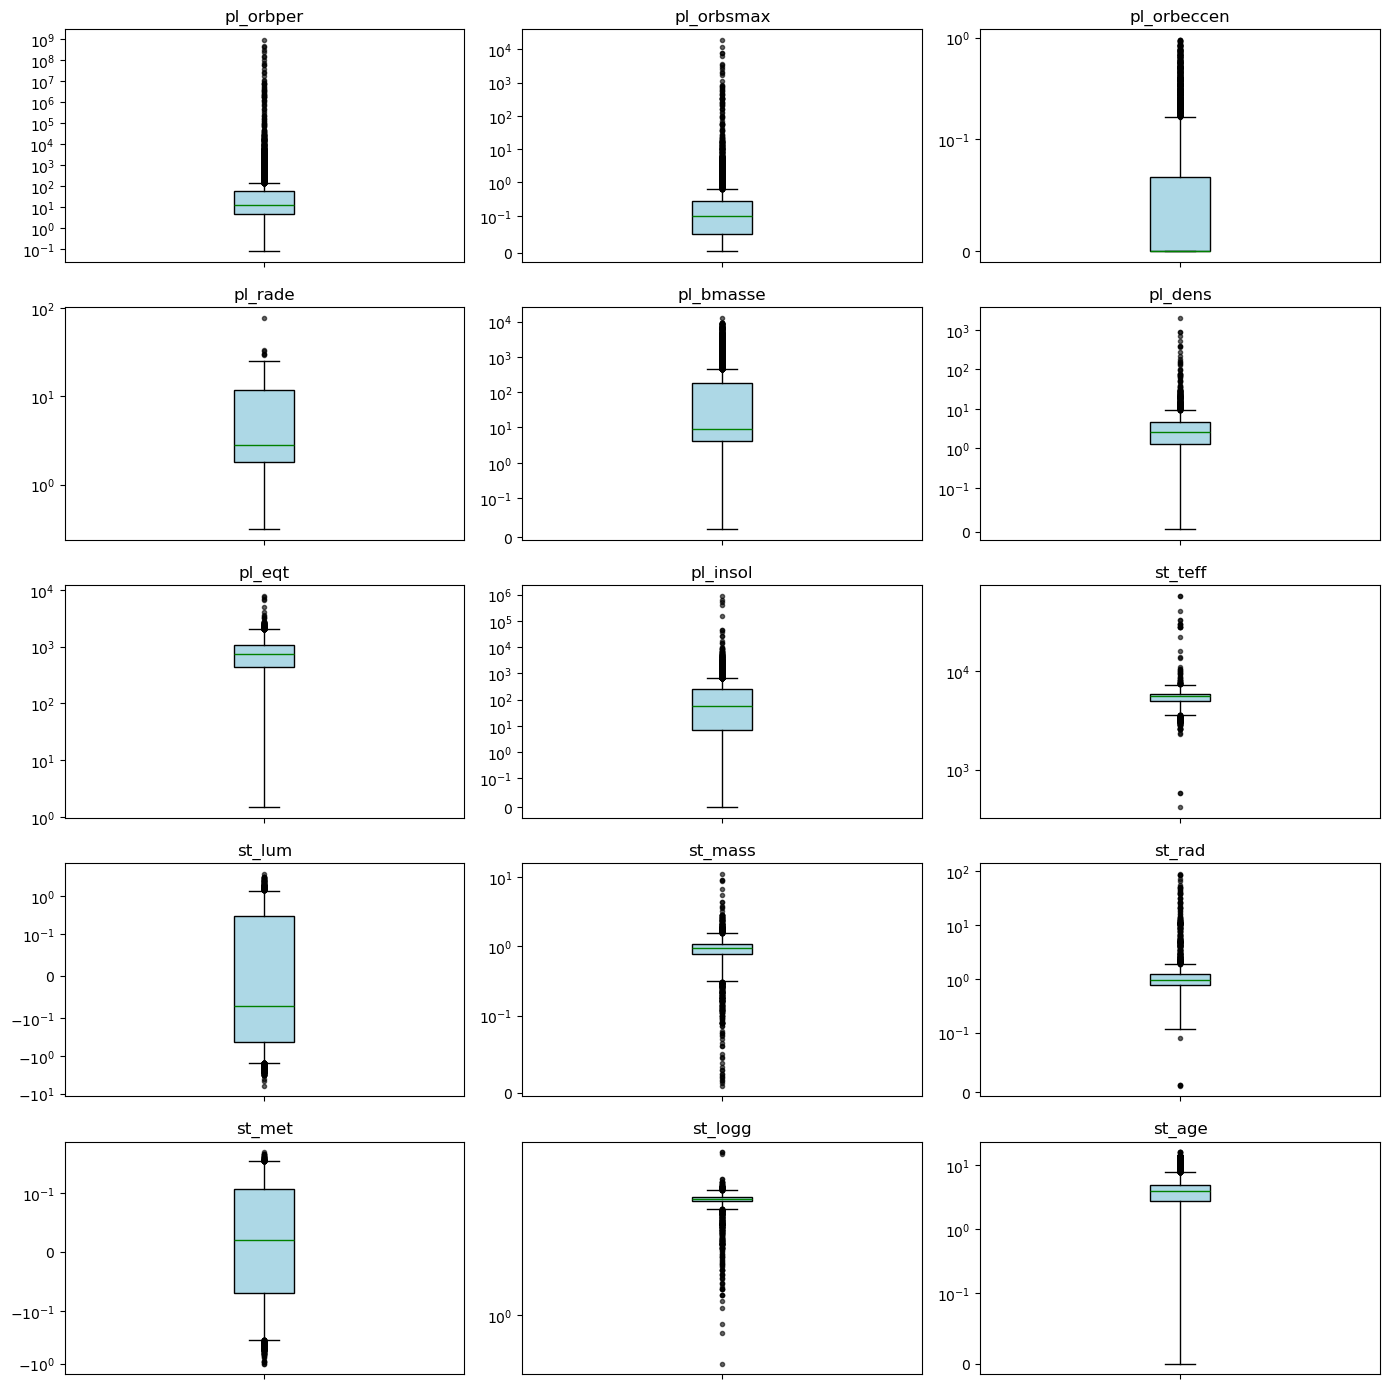

In [76]:
fig, axes = plt.subplots(5, 3, figsize=(14, 14))
axes = axes.flatten()

i = 0

for col in num_cols:
    axes[i].boxplot(
        df_work[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor="lightblue", color="black"),
        medianprops=dict(color="green", linewidth=1),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        flierprops=dict(marker='o', markerfacecolor='black', markersize=3, alpha=0.6)
    )

    axes[i].set_title(col)
    axes[i].tick_params(axis='x', labelbottom=False)
    axes[i].set_yscale('symlog', linthresh=0.1) # escala log que permite ver caja outliers sin aplastar tanto

    i = i + 1

plt.tight_layout()
plt.show()


**pl_orbper (periodo orbital)**
* Se observan outliers extremos correspondientes a planetas con periodos orbitales muy largos, que amplían notablemente la escala y provocan una distribución altamente asimétrica.

**pl_orbsmax (distancia a la estrella)**
* Los valores extremos generan una distribución fuertemente sesgada, coherente con los sesgos observacionales en la detección de exoplanetas.

**pl_orbeccen (excentricidad orbital)**
* La mayoría de planetas presentan órbitas de baja excentricidad, mientras que los valores altos aparecen como casos menos frecuentes pero relevantes desde el punto de vista dinámico.

**pl_rade (radio del planeta)**
* Se observan outliers correspondientes a planetas con radios muy grandes, asociados a planetas gigantes, que amplían la escala y generan una distribución claramente asimétrica.

**pl_bmasse (masa del planeta)**
* Estos outliers de alta masa provocan una distribución fuertemente sesgada, reflejando la coexistencia de planetas pequeños con gigantes extremadamente masivos.

**pl_dens (densidad del planeta)**
* Aparecen algunos valores extremos que se identifican como outliers, aunque con menor impacto que en otras variables, lo que permite diferenciar entre planetas rocosos y gaseosos.

**pl_eqt (temperatura de equilibrio)**
* Los outliers corresponden a planetas extremadamente calientes, que se alejan claramente del comportamiento medio del conjunto.

**pl_insol (radiación recibida)**
* Los outliers muestran casos de irradiación muy alta (planetas muy cercanos) y también valores muy bajos, reflejando una dispersión fuerte condicionada por la distancia orbital y la estrella anfitriona.


**st_teff (temperatura efectiva)**
* Los valores extremos aparecen como casos poco frecuentes, asociados a estrellas mucho más calientes o mucho más frías, que pueden implicar entornos de radiación distintos para sus planetas.

**st_lum (luminosidad)**
* Se observan valores extremos hacia luminosidades muy altas o muy bajas, compatibles con estrellas más energéticas o mucho menos brillantes, lo que impacta directamente en la energía disponible en el sistema.

**st_mass (masa estelar)**

* Los outliers corresponden a estrellas significativamente más masivas o menos masivas, que suelen tener comportamientos evolutivos distintos (vida más corta o más larga, respectivamente).

**st_rad (radio estelar)**

* Los valores extremos hacia radios grandes sugieren la presencia de estrellas hinchadas/evolucionadas, que pueden alterar la estabilidad del entorno a lo largo del tiempo.

**st_met (metallicidad)**

* Los valores extremos indican estrellas con composiciones muy distintas (más pobres o más ricas en “metales”), lo que puede influir en la probabilidad de formar planetas rocosos.

**st_logg (gravedad superficial)**

* Los valores bajos aparecen como casos extremos y son consistentes con estrellas más hinchadas/evolucionadas, que son menos interesantes para habitabilidad a largo plazo.

**st_age (edad)**

* Los valores extremos representan estrellas muy jóvenes o muy antiguas, lo que puede asociarse a entornos más activos (jóvenes) o más estables pero evolucionados (muy antiguas).

``Conclusión conjunta ``

Las variables orbitales muestran distribuciones altamente asimétricas y presencia de valores extremos, lo que justifica la necesidad de un escalado relativo posterior y de un enfoque basado en desviaciones relativas para la construcción del índice de habitabilidad.

Las variables asociadas a las propiedades físicas del planeta muestran distribuciones altamente asimétricas y una presencia clara de valores extremos, especialmente en masa, temperatura y radiación recibida. Este comportamiento refuerza la necesidad de aplicar un escalado relativo posterior y de utilizar un enfoque basado en desviaciones relativas para evitar que los valores extremos dominen el índice de habitabilidad.

Las variables estelares sugieren que muchas estrellas anfitrionas son cercanas a perfiles tipo solar (temperatura, masa y metallicidad alrededor de valores moderados), aunque existen casos extremos. Variables como st_rad y st_logg ayudan a detectar estrellas potencialmente evolucionadas, lo que es relevante para filtrar sistemas menos estables de cara a la habitabilidad a largo plazo.

In [77]:
# Tabla resumen numérica 
vars_index = vars_c + vars_d + vars_e
summary = df_work[vars_index].describe().T[['min','max','mean','std']]
summary

,min,max,mean,std
pl_orbper,9.070629e-02,8.768941e+08,506801.176508,1.493297e+07
pl_orbsmax,3.856670e-03,1.900000e+04,14.905010,3.433862e+02
pl_orbeccen,0.000000e+00,9.500000e-01,0.067133,1.431533e-01
pl_rade,3.098000e-01,7.734210e+01,5.793161,5.337645e+00
pl_bmasse,2.000000e-02,1.265150e+04,385.408151,1.106467e+03
pl_dens,5.100000e-03,2.000000e+03,4.879719,3.450930e+01
pl_eqt,1.481161e+00,7.777781e+03,812.477240,5.229454e+02
pl_insol,3.289901e-10,8.782908e+05,782.286152,1.648455e+04
st_teff,4.150000e+02,5.700000e+04,5417.099583,1.715163e+03
st_lum,-6.090000e+00,3.800000e+00,-0.132183,7.589986e-01


## 6. Tratamiento de outliers

Tras la revisión rápida de variables, tanto mediante histogramas como mediante boxplots, se observa un patrón común en gran parte de las magnitudes analizadas: distribuciones fuertemente asimétricas y concentradas cerca del origen, acompañadas de colas largas hacia valores elevados.

En los `histogramas`, muchas variables presentan la mayor parte de sus observaciones acumuladas en rangos muy bajos, mientras que el eje horizontal se extiende hasta valores muy altos debido a un número reducido de planetas con magnitudes extremas. Este efecto provoca que las distribuciones aparezcan “desplazadas” hacia la izquierda, evidenciando la presencia de observaciones muy alejadas del grueso de la muestra.

De forma complementaria, los `boxplots` confirman este comportamiento: las cajas intercuartílicas quedan comprimidas frente a rangos totales muy amplios, lo que dificulta la lectura visual y anticipa un impacto potencial sobre estadísticas sensibles a valores extremos, como la media, la desviación típica o determinadas relaciones de correlación.

Con el objetivo de cuantificar esta situación de forma sistemática, se aplica el criterio de Tukey (IQR) sobre una copia del dataset (`df_eda`). Este procedimiento se utiliza exclusivamente con fines diagnósticos, permitiendo identificar qué variables concentran un mayor número de observaciones extremas y estimar la magnitud del fenómeno en el conjunto de datos.

El recuento obtenido muestra que, en varias variables clave, el número de registros clasificados como outliers es elevado. En este contexto, una eliminación directa de observaciones no resulta adecuada, ya que implicaría descartar una fracción sustancial del dataset y comprometer su representatividad global.

También se considera la imputación directa de valores extremos (por ejemplo, mediante la mediana). Sin embargo, este enfoque altera artificialmente las distribuciones originales y puede generar nuevos valores atípicos en reevaluaciones posteriores. Además, en un dominio físico como el analizado, los valores extremos no necesariamente corresponden a errores de medida, sino que pueden reflejar configuraciones planetarias reales, aunque poco frecuentes.

Por estos motivos, el criterio de Tukey se mantiene en esta fase como herramienta exploratoria, no como mecanismo de limpieza directa.


In [78]:
df_outlier_diag = df_work.copy()

def filtrar_outlier_tukey(x, threshold=1.5):

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)

    iqr = q3 - q1
    print(f'[q1={q1}, q3={q3}, iqr={iqr}]')

    floor = q1 - threshold * iqr
    ceiling = q3 + threshold * iqr
    print(f'[floor={floor}, ceiling={ceiling}]')

    outlier_indices = list(x.index[(x < floor) | (x > ceiling)])
    outlier_values = list(x[outlier_indices])

    return outlier_indices, outlier_values


In [79]:
n_outliers = {}

for col in num_cols:
    outlier_indices, outlier_values = filtrar_outlier_tukey(df_outlier_diag[col])
    n_outliers[col] = len(outlier_indices)

pd.Series(n_outliers).sort_values(ascending=False)



[q1=4.55139967, q3=56.35850143, iqr=51.807101759999995]
[floor=-73.15925297, ceiling=134.06915407]
[q1=0.052, q3=0.286, iqr=0.23399999999999999]
[floor=-0.299, ceiling=0.637]
[q1=0.0, q3=0.066, iqr=0.066]
[floor=-0.099, ceiling=0.165]
[q1=1.82, q3=11.9, iqr=10.08]
[floor=-13.3, ceiling=27.020000000000003]
[q1=4.16, q3=179.89178, iqr=175.73178000000001]
[floor=-259.43766999999997, ceiling=443.48945000000003]
[q1=1.32, q3=4.54, iqr=3.2199999999999998]
[floor=-3.51, ceiling=9.370000000000001]
[q1=443.66768868882133, q3=1075.0, iqr=631.3323113111787]
[floor=-503.33077827794676, ceiling=2021.998466966768]
[q1=7.13, q3=261.628, iqr=254.498]
[floor=-374.61699999999996, ceiling=643.375]
[q1=4952.0, q3=5885.38, iqr=933.3800000000001]
[floor=3551.93, ceiling=7285.450000000001]
[q1=-0.43985, q3=0.297, iqr=0.73685]
[floor=-1.545125, ceiling=1.402275]
[q1=0.778, q3=1.09, iqr=0.31200000000000006]
[floor=0.30999999999999994, ceiling=1.5580000000000003]
[q1=0.781, q3=1.23, iqr=0.44899999999999995]
[fl

pl_orbper      1176
pl_orbsmax     1082
pl_bmasse       988
pl_orbeccen     872
pl_insol        826
st_age          580
st_lum          462
st_mass         441
st_logg         436
st_rad          411
st_teff         356
pl_dens         309
st_met          274
pl_eqt          136
pl_rade           6
dtype: int64

Podemos observar el recuento de Outliers, detectado por Tukey en cada una de las variables. 

Para su tratamiento, se adopta una estrategia de `winsorización` basada en los límites definidos por Tukey. Este procedimiento consiste en identificar, para cada variable, un umbral inferior y superior (a partir del rango intercuartílico) y sustituir únicamente los valores que quedan fuera de dichos límites por el propio valor del umbral correspondiente. Es decir, los valores extremadamente bajos se elevan hasta el límite inferior, y los extremadamente altos se reducen hasta el límite superior.

De este modo, no se eliminan observaciones ni se reemplazan por valores centrales (como la mediana), sino que se mantiene cada registro dentro de su variable, limitando únicamente la influencia de magnitudes extremas. La información estructural del dataset se conserva, pero se evita que unos pocos valores muy alejados del rango típico distorsionen las escalas y las métricas posteriores.

La winsorización resulta especialmente adecuada en este trabajo por tres motivos principales:

1) **Robustez y estabilidad**: al recortar solo los extremos, se reduce la sensibilidad de estadísticas como la media, la desviación típica o ciertas correlaciones frente a valores muy altos o muy bajos, estabilizando el análisis sin alterar de forma significativa el comportamiento del grueso de la distribución.

2) **Conservación de información**: a diferencia del `drop`, se preserva el tamaño muestral y la representatividad del dataset. Además, a diferencia de la imputación por mediana, no se homogeneizan artificialmente observaciones muy distintas: un planeta “más caliente” que otro sigue siéndolo, aunque su valor quede acotado dentro de un rango razonable.

3) **Coherencia con el objetivo del índice de habitabilidad**: los planetas potencialmente similares a la Tierra se concentran en regiones próximas a valores moderados de masa, temperatura o insolación. Los casos extremos, aunque físicamente reales, son candidatos poco plausibles y, si no se controla su influencia, pueden dominar el cálculo del índice. La winsorización permite que el ranking final esté guiado por el patrón general del conjunto de datos y no por unos pocos valores extremos aislados.

Este enfoque representa un compromiso entre robustez estadística y preservación del significado físico de las variables. El efecto del procedimiento se valida visualmente mediante boxplots, observándose una reducción clara del impacto de colas largas sin pérdida de observaciones, preparando así el dataset para las fases posteriores de análisis y construcción del índice de habitabilidad.



In [80]:
def winsorizar_tukey(x, threshold=1.5):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    floor = q1 - threshold * iqr
    ceiling = q3 + threshold * iqr

    return x.clip(lower=floor, upper=ceiling)


In [81]:
# Hacemos una copia del df_work para tener un df winsorizado con los outliers
df_wins = df_work.copy()

for col in num_cols:
    df_wins[col] = winsorizar_tukey(df_wins[col])


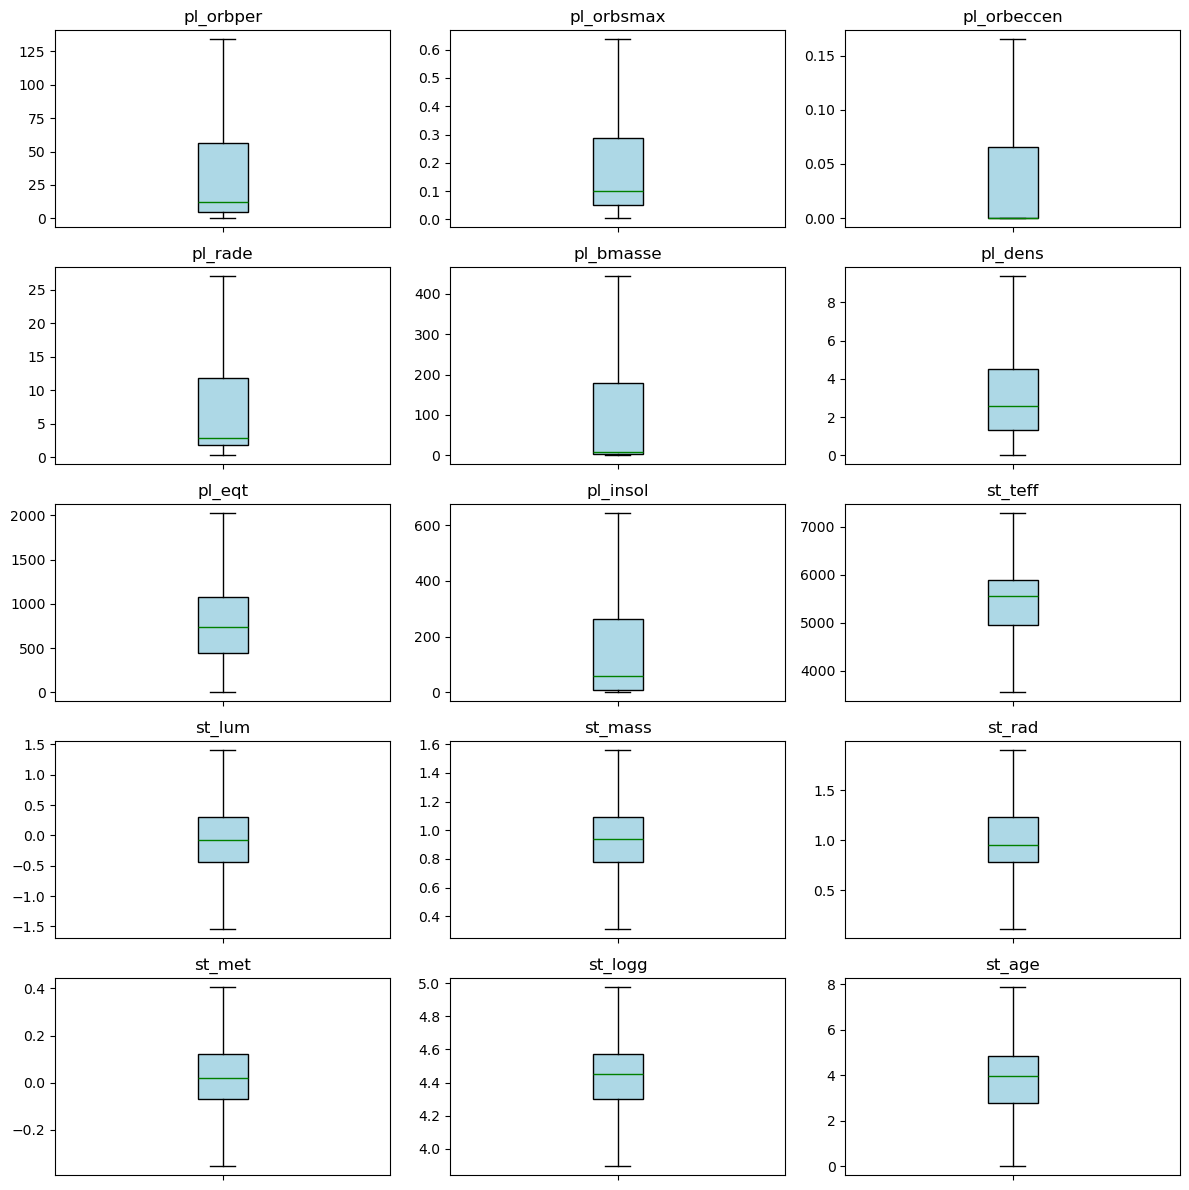

In [82]:
fig, axes = plt.subplots(5, 3, figsize=(12, 12))
axes = axes.flatten()

i = 0

for col in num_cols:
    axes[i].boxplot(
    df_wins[col].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="black"),
    medianprops=dict(color="green", linewidth=1),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black")
)

    axes[i].set_title(col)
    axes[i].tick_params(axis='x', labelbottom=False)
    i = i + 1

plt.tight_layout()
plt.show()


## 7. Caracterización estadística del dataset final

Una vez estabilizadas las distribuciones mediante winsorización, se dispone de un conjunto de variables en el que el efecto de valores extremos ha sido controlado, sin pérdida de observaciones ni alteración del significado físico de los datos. Esto permite abordar el análisis descriptivo sobre una base más robusta, en la que las métricas resumen reflejan mejor el comportamiento global del conjunto de planetas.

En este apartado se calculan estadísticas básicas (medidas de centralidad y dispersión) para las variables seleccionadas, con el objetivo de caracterizar sus rangos típicos, identificar patrones generales y sentar las bases para el análisis de correlaciones y la posterior construcción del índice de habitabilidad.


In [83]:
# Hacemos una copia con el df final que vamos a trabajar a partir de ahora

df_final = df_wins.copy() 

In [84]:
df_final.head(5)

,objectid,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
0,3.10209,K2-178 b,K2-178,8.747818,0.081711,0.000,3.55791,12.40000,1.510,840.290000,117.826000,5525.00,-0.283820,0.95109,0.887267,0.09,4.550,3.980
1,3.19225,HD 74698 c,HD 74698,134.069154,0.637000,0.165,14.00000,126.00000,0.252,151.773321,0.088000,5783.00,0.252850,1.03900,1.333000,0.07,4.120,7.847
2,3.12241,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,134.069154,0.637000,0.000,12.70000,443.48945,5.900,115.771234,0.032603,5554.00,-0.071600,0.45000,0.953000,0.02,4.453,3.980
3,3.12499,GJ 1061 b,GJ 1061,3.204000,0.021000,0.165,1.10000,1.37000,5.660,388.105256,3.800000,3551.93,-1.545125,0.31000,0.156000,-0.08,4.975,7.000
4,3.2527,Kepler-102 b,Kepler-102,5.286965,0.055210,0.100,0.46000,1.10000,9.370,857.000000,90.000000,4909.00,-0.584360,0.80300,0.724000,0.11,4.600,1.100


Una vez completado el proceso de tratamiento de **NaN** y **Outliers** y antes de proceder al análisis formal del dataset final, se comparan a continuación los estadísticos descriptivos del conjunto tras la imputación (df_work) y del conjunto definitivo tras la winsorización (df_final). El objetivo de esta comparación es evaluar de forma explícita el impacto del tratamiento de valores extremos sobre las medidas de centralidad y dispersión, y verificar que dicho proceso actúa principalmente sobre las colas de las distribuciones.

In [85]:
# Antes winsorización para tratar los outliers
df_work[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
pl_orbper,6021.0,506801.176508,1.493297e+07,9.070629e-02,4.551400,12.309681,56.358501,8.768941e+08
pl_orbsmax,6021.0,14.905010,3.433862e+02,3.856670e-03,0.052000,0.100000,0.286000,1.900000e+04
pl_orbeccen,6021.0,0.067133,1.431533e-01,0.000000e+00,0.000000,0.000000,0.066000,9.500000e-01
pl_rade,6021.0,5.793161,5.337645e+00,3.098000e-01,1.820000,2.830000,11.900000,7.734210e+01
pl_bmasse,6021.0,385.408151,1.106467e+03,2.000000e-02,4.160000,9.100000,179.891780,1.265150e+04
pl_dens,6021.0,4.879719,3.450930e+01,5.100000e-03,1.320000,2.560000,4.540000,2.000000e+03
pl_eqt,6021.0,812.477240,5.229454e+02,1.481161e+00,443.667689,733.000000,1075.000000,7.777781e+03
pl_insol,6021.0,782.286152,1.648455e+04,3.289901e-10,7.130000,57.630734,261.628000,8.782908e+05
st_teff,6021.0,5417.099583,1.715163e+03,4.150000e+02,4952.000000,5554.000000,5885.380000,5.700000e+04
st_lum,6021.0,-0.132183,7.589986e-01,-6.090000e+00,-0.439850,-0.071600,0.297000,3.800000e+00


In [86]:
# Después de la winsorización para tratar los outliers

df_final[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pl_orbper,6021.0,39.935950,50.760766,9.070629e-02,4.551400,12.309681,56.358501,134.069154
pl_orbsmax,6021.0,0.210623,0.223685,3.856670e-03,0.052000,0.100000,0.286000,0.637000
pl_orbeccen,6021.0,0.038713,0.062729,0.000000e+00,0.000000,0.000000,0.066000,0.165000
pl_rade,6021.0,5.781285,5.248657,3.098000e-01,1.820000,2.830000,11.900000,27.020000
pl_bmasse,6021.0,111.056395,169.654119,2.000000e-02,4.160000,9.100000,179.891780,443.489450
pl_dens,6021.0,3.127858,2.358211,5.100000e-03,1.320000,2.560000,4.540000,9.370000
pl_eqt,6021.0,801.980014,473.456201,1.481161e+00,443.667689,733.000000,1075.000000,2021.998467
pl_insol,6021.0,176.102865,228.621856,3.289901e-10,7.130000,57.630734,261.628000,643.375000
st_teff,6021.0,5356.568592,794.518906,3.551930e+03,4952.000000,5554.000000,5885.380000,7285.450000
st_lum,6021.0,-0.118290,0.644695,-1.545125e+00,-0.439850,-0.071600,0.297000,1.402275


La comparación entre ambos resúmenes estadísticos muestra una reducción muy marcada de los valores máximos, medias y desviaciones típicas en varias variables clave, como el **periodo orbital**, la **masa planetaria**, la **insolación** o el **radio estelar**, evidenciando la presencia previa de colas largas dominadas por observaciones extremas. Por ejemplo, en `pl_orbper`, el valor máximo pasa de 8.8×10⁸ a 134, y la media se reduce varios órdenes de magnitud, mientras que los cuartiles permanecen cercanos.

Por ejemplo, en pl_orbper, el valor máximo pasa de ser enorme (del orden de millones) a 134, mientras que el valor medio también baja mucho. Sin embargo, los valores centrales del conjunto (los típicos) apenas cambian.

Esto significa que el tratamiento aplicado actúa sobre unos pocos casos extremos, pero deja prácticamente igual al grueso de los datos.

En resumen: se han reducido los valores raros sin alterar el comportamiento general del dataset, dejando una base más limpia y estable para analizar relaciones entre variables y construir el índice de habitabilidad.

### Comparación media–mediana y análisis de asimetría
Con el objetivo de evaluar la posible asimetría de las distribuciones tras el tratamiento de valores extremos, se comparan a continuación la media y la mediana de cada variable. Esta comparación permite identificar qué variables presentan todavía sesgo, ya que diferencias marcadas entre ambos estadísticos indican distribuciones no simétricas. Este análisis resulta relevante de cara a los pasos posteriores, en particular para justificar la necesidad de un escalado relativo antes de la construcción del índice de habitabilidad.

In [87]:
round(df_final.describe().T[["mean","50%"]], 2)

,mean,50%
pl_orbper,39.94,12.31
pl_orbsmax,0.21,0.10
pl_orbeccen,0.04,0.00
pl_rade,5.78,2.83
pl_bmasse,111.06,9.10
pl_dens,3.13,2.56
pl_eqt,801.98,733.00
pl_insol,176.10,57.63
st_teff,5356.57,5554.00
st_lum,-0.12,-0.07


Al comparar la media con la mediana se ve que, incluso después de recortar valores extremos, algunas variables de los planetas siguen teniendo valores muy desiguales.

En concreto, en cosas como el **periodo orbital**, la **masa del planeta**, la **insolación** o el **radio del planeta**, la media es bastante mayor que la mediana. Esto significa que todavía hay algunos planetas con valores muy altos que empujan la media hacia arriba, aunque sean pocos.

En cambio, las variables de las estrellas (**masa**, **radio**, **metalicidad**, **gravedad superficial** y **edad**) tienen medias muy parecidas a sus medianas, lo que indica que están mucho mejor repartidas y son más “normales”.

En resumen:
los planetas siguen siendo muy variados entre sí, mientras que las estrellas son bastante parecidas. Por eso, antes de calcular el índice de habitabilidad, es necesario reescalar las variables, para que ninguna domine el resultado solo por tener valores más grandes.

## 8. Análisis de Correlaciones

Una vez caracterizado estadísticamente el dataset final y estabilizadas las distribuciones mediante winsorización, el siguiente paso consiste en analizar las relaciones existentes entre las variables físicas seleccionadas.
Este análisis permite identificar dependencias estructurales, posibles redundancias y patrones de co-variación entre parámetros planetarios y estelares, proporcionando una visión global del espacio físico en el que se construirá posteriormente el índice de habitabilidad.

Con el objetivo de analizar de forma global las relaciones entre las variables físicas seleccionadas, se calcula inicialmente la matriz de correlación del dataset final. Esta tabla numérica permite identificar dependencias estructurales, posibles redundancias y patrones generales de co-variación entre parámetros planetarios y estelares, proporcionando una primera aproximación al espacio físico sobre el que se construirá posteriormente el índice de habitabilidad.

In [88]:
df_final[num_cols].corr()


,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
pl_orbper,1.000000,0.992814,0.366592,0.447333,0.507963,-0.004128,-0.612182,-0.492896,0.025137,0.236470,0.048309,0.220907,-0.006439,-0.244038,-0.025003
pl_orbsmax,0.992814,1.000000,0.368408,0.455034,0.518043,-0.004315,-0.612117,-0.499696,0.060691,0.275197,0.083070,0.257459,0.001384,-0.280275,-0.029996
pl_orbeccen,0.366592,0.368408,1.000000,0.399258,0.428950,0.007249,-0.203283,-0.160815,-0.069981,0.117118,0.149788,0.194464,0.076254,-0.195919,0.082985
pl_rade,0.447333,0.455034,0.399258,1.000000,0.837581,-0.291891,0.055833,0.109561,0.188084,0.369917,0.318665,0.439589,0.190004,-0.423315,-0.035423
pl_bmasse,0.507963,0.518043,0.428950,0.837581,1.000000,0.039358,-0.023202,0.029828,0.122672,0.346021,0.298377,0.397750,0.153984,-0.377164,-0.067168
pl_dens,-0.004128,-0.004315,0.007249,-0.291891,0.039358,1.000000,0.004860,-0.009872,-0.122656,-0.081889,-0.073844,-0.102311,-0.104902,0.105347,-0.044037
pl_eqt,-0.612182,-0.612117,-0.203283,0.055833,-0.023202,0.004860,1.000000,0.874789,0.339368,0.294229,0.385216,0.304494,0.098435,-0.270234,-0.053794
pl_insol,-0.492896,-0.499696,-0.160815,0.109561,0.029828,-0.009872,0.874789,1.000000,0.361088,0.318163,0.367367,0.312891,0.138440,-0.279274,-0.014139
st_teff,0.025137,0.060691,-0.069981,0.188084,0.122672,-0.122656,0.339368,0.361088,1.000000,0.758049,0.692490,0.610936,0.141769,-0.568142,-0.121595
st_lum,0.236470,0.275197,0.117118,0.369917,0.346021,-0.081889,0.294229,0.318163,0.758049,1.000000,0.835768,0.890887,0.123723,-0.860900,-0.075210


##### Visualización de la matriz de correlación

Dado que la matriz de correlación en formato tabular resulta poco intuitiva cuando el número de variables es elevado, se representa a continuación mediante un mapa de calor (heatmap). Esta visualización facilita la identificación rápida de relaciones fuertes positivas o negativas entre variables, así como agrupaciones naturales entre parámetros planetarios y estelares.


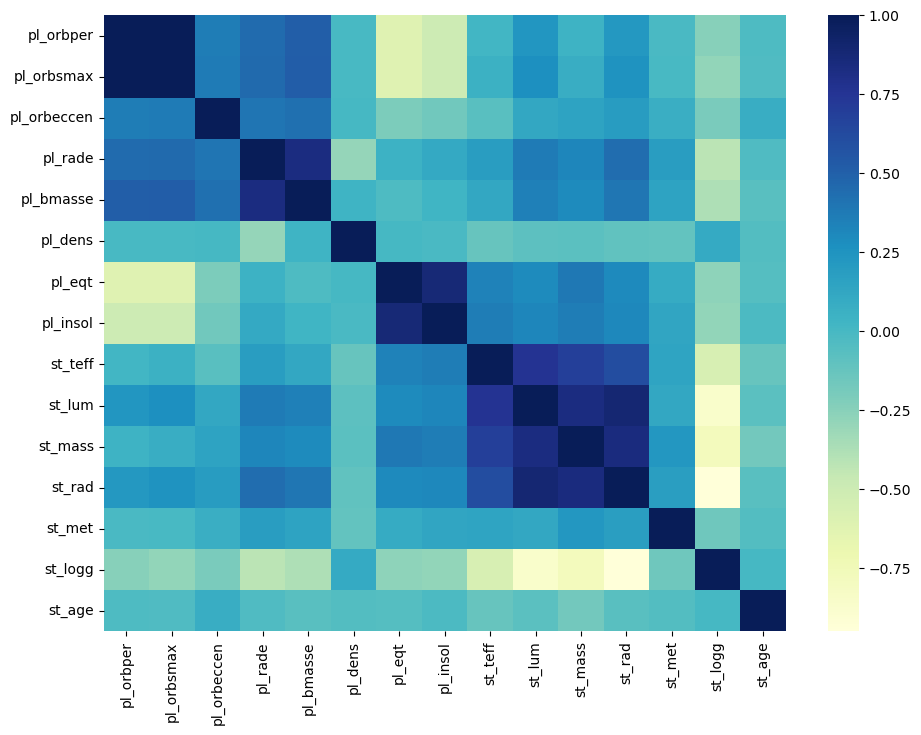

In [98]:
corr = df_final[num_cols].corr()

plt.figure(figsize=(11,8))
sns.heatmap(corr, cmap="YlGnBu", annot=False)

plt.show()

#### **Interpretación de la matriz de correlación**

A partir de la matriz de correlaciones del dataset final se observan varios bloques claros de dependencia entre variables, coherentes con la física del sistema planeta–estrella:

#### 1. ``Variables orbitales``

**pl_orbper – pl_orbsmax**: correlación extremadamente alta (r = 0.99).
Ambas variables describen esencialmente la misma escala orbital (leyes de Kepler), por lo que aportan información parcialmente redundante.

Estas variables presentan correlaciones negativas moderadas con:

* pl_eqt: ≈ −0.61
* pl_insol: ≈ −0.50

Órbitas más largas y lejanas se asocian con menor temperatura de equilibrio e insolación, como es físicamente esperable.

#### 2. ``Tamaño y masa planetaria``

* **pl_rade – pl_bmasse**: correlación fuerte (r = 0.84).
Refleja la relación física directa entre radio y masa planetaria.

* Ambas variables muestran correlaciones moderadas con parámetros estelares (≈ 0.30–0.44), indicando cierta dependencia del tipo de estrella hospedadora.

* **pl_dens** presenta correlaciones muy bajas con casi todas las variables (|r| < 0.15 en la mayoría de casos).
La densidad aporta información relativamente independiente, útil para discriminar composición planetaria.

#### 3. ``Temperatura de equilibrio e insolación``

* **pl_eqt – pl_insol**: correlación muy elevada (r = 0.87).
Ambas derivan directamente del flujo estelar recibido.

* También muestran correlaciones positivas con variables estelares:

    * con st_teff: ≈ 0.34–0.36
    * con st_lum: ≈ 0.29–0.32

#### 4. ``Parámetros estelares (bloque fuertemente correlacionado)``

Se identifica un bloque estelar muy claro:

* st_lum – st_rad: r = 0.89
* st_lum – st_mass: r = 0.84
* st_mass – st_rad: r = 0.84
* **st_teff **correlaciona con todas ellas (≈ 0.61–0.76)

Masa, radio, temperatura efectiva y luminosidad estelar están fuertemente acopladas, como dicta la estructura estelar.

Por el contrario:

**st_logg** muestra correlaciones negativas muy fuertes:
* con st_rad: r = −0.95
* con st_lum: r = −0.86
* con st_mass: r = −0.78

Coherente con su definición como gravedad superficial.

#### 5. ``Edad y metalicidad``

* **st_age**: correlaciones muy débiles con todas las variables (|r| < 0.17).
La edad estelar aporta información prácticamente independiente.

* *st_met*: correlaciones bajas o moderadas (máximo ≈ 0.23).
No aparece como factor dominante en este conjunto.

Para complementar la lectura visual del heatmap, se identifican explícitamente los pares de variables con correlación más alta. Esto permite resumir de forma objetiva qué relaciones son más fuertes.

In [90]:
# Matriz de correlación (Pearson)
corr = df_final[num_cols].corr()

umbral = 0.80  # correlación "alta"

cols = list(corr.columns)
filas = []

for i in range(len(cols)):
    for j in range(i+1, len(cols)):  # evita duplicados y diagonal
        v1 = cols[i]
        v2 = cols[j]
        r = corr.loc[v1, v2]
        if abs(r) >= umbral:
            filas.append([v1, v2, r, abs(r)])

pares_altos = pd.DataFrame(filas, columns=["var_1", "var_2", "r", "abs_r"])
pares_altos = pares_altos.sort_values("abs_r", ascending=False).reset_index(drop=True)

pares_altos


,var_1,var_2,r,abs_r
0,pl_orbper,pl_orbsmax,0.992814,0.992814
1,st_rad,st_logg,-0.949039,0.949039
2,st_lum,st_rad,0.890887,0.890887
3,pl_eqt,pl_insol,0.874789,0.874789
4,st_lum,st_logg,-0.860900,0.860900
5,st_mass,st_rad,0.844896,0.844896
6,pl_rade,pl_bmasse,0.837581,0.837581
7,st_lum,st_mass,0.835768,0.835768


El listado anterior recoge los pares con correlación absoluta superior al umbral fijado. En este proyecto, estas correlaciones altas se interpretan como dependencias físicas esperables entre magnitudes del sistema planeta–estrella, y se utilizan para resumir redundancias parciales sin eliminar variables, ya que el índice posterior se construirá en un espacio multivariante donde dichas dependencias forman parte natural del dominio.

#### **Interpretación de los pares altamente correlacionados**

El análisis explícito de los pares con correlación fuerte revela varias relaciones físicas claras entre parámetros orbitales, planetarios y estelares, coherentes con la estructura del sistema planeta–estrella:

#### 1. Escala orbital y entorno energético del planeta

La relación extrema entre periodo orbital y semieje mayor confirma que ambas variables describen esencialmente la misma dimensión física: la escala orbital del planeta. En la práctica, esto implica que la distancia a la estrella determina directamente el régimen energético del planeta.

Esta escala orbital controla también la temperatura de equilibrio y la insolación: planetas más cercanos reciben mayor flujo estelar y presentan temperaturas más elevadas, mientras que órbitas más amplias conducen a entornos fríos y con baja irradiación. Por tanto, la geometría orbital es el principal condicionante del entorno térmico del planeta.

#### 2. Tamaño y masa planetaria

La fuerte relación entre radio y masa planetaria refleja la estructura física básica de los planetas: cuerpos más grandes tienden a ser también más masivos. Ambas variables describen conjuntamente el tamaño del planeta, aunque no son completamente independientes.

Este acoplamiento sugiere que volumen y gravedad superficial evolucionan de forma conjunta, influyendo indirectamente en procesos como la retención atmosférica y las condiciones de superficie.

#### 3. Temperatura de equilibrio e insolación

La temperatura de equilibrio y la insolación aparecen prácticamente ligadas entre sí, lo cual es esperable dado que ambas derivan directamente del flujo estelar recibido.

En términos prácticos, el estado térmico del planeta está dominado por la energía procedente de su estrella, reforzando el papel central del entorno energético en cualquier evaluación de habitabilidad.

#### 4. Bloque estelar: masa, radio y luminosidad

Los parámetros estelares forman un bloque altamente acoplado: estrellas más masivas tienden a ser más grandes y luminosas. Este conjunto de variables caracteriza el tipo de estrella hospedadora y define el marco energético del sistema.

Como consecuencia, las propiedades estelares condicionan indirectamente los parámetros planetarios dependientes del flujo recibido, estableciendo el contexto físico global del sistema.

Por otro lado, la gravedad superficial estelar muestra una relación inversa con radio y luminosidad: estrellas grandes y brillantes presentan menor gravedad superficial, coherente con su definición física.

#### Conclusiónes

En conjunto, estos resultados muestran que el sistema planeta–estrella se organiza en varios bloques físicos acoplados.Esto confirma que muchas variables no son independientes, sino distintas proyecciones del mismo sistema físico. 

Aun así, cada bloque aporta información complementaria, lo que justifica el uso posterior de un índice multivariante para integrar todas las dimensiones y caracterizar de forma global la habitabilidad potencial.

## 9. Construcción del vector Tierra

Tras analizar las relaciones entre variables, se establece el punto de referencia físico frente al cual se evaluará cada exoplaneta: el vector Tierra. Este vector representa las condiciones Tierra–Sol para todas las magnitudes consideradas y define el centro del espacio físico en el que se comparan los planetas.

Dado que el dataset de la NASA contiene exclusivamente exoplanetas y no incluye la Tierra, este vector se construye de forma externa, utilizando valores físicos estándar de la literatura astronómica, expresados explícitamente en las mismas unidades que las variables del dataset. Previamente se verificó la coherencia de dichas unidades mediante contrastes físicos (ley de Kepler e insolación), garantizando la compatibilidad entre ambos espacios.

In [91]:
# Vector Tierra (valores de referencia Tierra-Sol, en las mismas unidades del dataset)
earth_values = {
    # Órbita (Tierra alrededor del Sol)
    "pl_orbper": 365.25,     # días
    "pl_orbsmax": 1.0,       # AU
    "pl_orbeccen": 0.0167,   # adimensional

    # Planeta (Tierra)
    "pl_rade": 1.0,          # radios Tierra
    "pl_bmasse": 1.0,        # masas Tierra
    "pl_dens": 5.51,         # g/cm^3 (densidad media Tierra)
    "pl_eqt": 255.0,         # K (temperatura de equilibrio aproximada)
    "pl_insol": 1.0,         # flujo relativo a la Tierra

    # Estrella (Sol)
    "st_teff": 5778.0,       # K
    "st_lum": 0.0,           # log10(L/Lsun) -> Sol = 0
    "st_mass": 1.0,          # masas solares
    "st_rad": 1.0,           # radios solares
    "st_met": 0.0,           # [Fe/H]
    "st_logg": 4.44,         # log(g) cgs
    "st_age": 4.6            # Gyr
}

# Construimos la Series en el MISMO orden de columnas que df_final
vector_tierra = pd.Series(earth_values)[num_cols]
vector_tierra.name = "Tierra"

vector_tierra


pl_orbper       365.2500
pl_orbsmax        1.0000
pl_orbeccen       0.0167
pl_rade           1.0000
pl_bmasse         1.0000
pl_dens           5.5100
pl_eqt          255.0000
pl_insol          1.0000
st_teff        5778.0000
st_lum            0.0000
st_mass           1.0000
st_rad            1.0000
st_met            0.0000
st_logg           4.4400
st_age            4.6000
Name: Tierra, dtype: float64

Una vez definido el vector Tierra, ya disponemos de un punto de referencia físico común frente al cual comparar todos los exoplanetas del dataset. Cada planeta puede interpretarse ahora como un conjunto de propiedades físicas cuya distancia respecto a este vector refleja su grado de similitud con las condiciones terrestres.

No obstante, las variables consideradas operan en escalas muy distintas (por ejemplo, masas, temperaturas o radios), por lo que una comparación directa estaría dominada por aquellas magnitudes con valores numéricamente más grandes. Para evitar este efecto y asegurar que todas las variables contribuyen de forma equilibrada al cálculo del índice, el siguiente paso consiste n aplicar un escalado relativo del dataset antes de evaluar las desviaciones respecto al vector Tierra.

## 10. Escalado relativo de variables

Una vez definido el vector Tierra como referencia física, el siguiente paso consiste en reescalar las variables para poder comparar magnitudes heterogéneas dentro de un mismo marco común.

Dado que las variables consideradas presentan unidades y órdenes de magnitud muy diferentes, se adopta un enfoque de escalado relativo basado en percentiles, ES DECIR, para cada dimensión se calcula la desviación respecto al valor terrestre y se expresa como fracción de su rango típico (P99–P01). De este modo, cada variable pasa a representar “cuánto se aleja” del estado Tierra, independientemente de su unidad original.

Este procedimiento permite transformar el problema en una comparación directa de desviaciones físicas relativas, preparando el dataset para el cálculo posterior de distancias multivariantes y la construcción del índice de habitabilidad.

## 11. Cálculo de desviación por variable

Una vez reescaladas las variables y definidas las condiciones de referencia terrestres, se calcula para cada planeta la desviación individual respecto al vector Tierra en cada dimensión física.

Este paso permite cuantificar, variable a variable, cuánto se aleja cada exoplaneta de las condiciones terrestres, descomponiendo la diferencia global en contribuciones específicas asociadas a cada parámetro físico.

## 12. Agregación de desviaciones

A continuación, las desviaciones individuales se combinan en una única medida compuesta que resume el alejamiento total de cada planeta respecto al vector Tierra.
Esta agregación transforma el conjunto de discrepancias parciales en una magnitud escalar, equivalente a una distancia global dentro del espacio físico definido, permitiendo comparar directamente exoplanetas según su proximidad al estado terrestre.

## 13. Cálculo del índice de habitabilidad

Con la distancia global respecto al vector Tierra ya calculada, se construye el índice de habitabilidad como una transformación directa de dicha medida.

Cada exoplaneta queda representado como un punto en el espacio reescalado de variables, mientras que la Tierra actúa como vector de referencia. El índice cuantifica lo próximo que se encuentra cada planeta a este estado terrestre ideal, de modo que valores menores de distancia implican mayor similitud y, por tanto, mayor habitabilidad relativa dentro del conjunto analizado.

El enfoque adoptado evita introducir ponderaciones arbitrarias entre variables y trata todas las dimensiones físicas de forma equivalente. De este modo, la habitabilidad se evalúa exclusivamente en función de la proximidad conjunta al estado terrestre, sin imponer pesos subjetivos ni criterios externos. Esta elección prioriza un criterio objetivo, reproducible y físicamente interpretable.

El índice resultante no pretende modelar procesos biológicos ni climáticos complejos, sino proporcionar una métrica sintética de similitud planetaria basada en propiedades físicas observables. A partir de este índice se genera posteriormente un ranking de exoplanetas, que permite identificar de forma directa aquellos objetos que presentan características más cercanas a las de la Tierra dentro del dataset disponible.

## 14. Generación del ranking

Una vez calculado el índice de habitabilidad para cada exoplaneta, el siguiente paso consiste en ordenar todos los planetas en función de dicho índice. Este ranking permite identificar de forma directa cuáles son los exoplanetas más similares a la Tierra según el criterio definido, convirtiendo el índice en una herramienta práctica de priorización y comparación.

## 15. Interpretación del Top
A partir del ranking obtenido, se analizan los planetas mejor posicionados con el objetivo de interpretar sus características físicas y comprender qué factores están impulsando su alta puntuación de habitabilidad. Este análisis permite conectar el resultado numérico del índice con propiedades planetarias concretas, aportando una lectura física y cualitativa de los exoplanetas más prometedores.

## 16. Validación exploratoria (gráficos)
Una vez obtenido el ranking de habitabilidad, se realiza una validación exploratoria del índice mediante representaciones gráficas con el objetivo de evaluar la coherencia global de los resultados y comprender el comportamiento del índice sobre el conjunto completo de exoplanetas.

En primer lugar, se analiza la distribución del índice de habitabilidad mediante un **histograma**, lo que permite observar su forma, dispersión y posible presencia de colas largas o concentraciones, así como comprobar si existe una separación clara entre los planetas mejor clasificados y el resto del conjunto.

Complementariamente, se emplea un **boxplot** del índice para caracterizar su distribución central, identificar valores extremos y evaluar la variabilidad global del indicador.

A continuación, se comparan las características físicas medias de los planetas mejor posicionados en el ranking con las del resto del dataset, con el fin de comprobar si el índice está capturando diferencias reales en variables relevantes como radio planetario, masa, temperatura o insolación. Esta comparación permite validar de forma intuitiva que los planetas con mayor índice presentan, en promedio, propiedades más cercanas a las condiciones terrestres.

Finalmente, se exploran relaciones simples entre el índice y algunas variables físicas clave mediante representaciones bivariantes, con el objetivo de identificar tendencias generales y reforzar la interpretación física del resultado obtenido.

En conjunto, esta validación gráfica permite detectar posibles anomalías, verificar la separación entre grupos y aportar una primera evidencia visual de la coherencia del índice construido.

## 17. Análisis de sensibilidad

Además de la validación visual, se lleva a cabo un análisis de sensibilidad para evaluar la robustez del índice de habitabilidad frente a pequeñas variaciones en los datos o en el procedimiento de cálculo.

Este análisis consiste en introducir perturbaciones controladas en las variables reescaladas y recalcular el índice, así como en repetir el proceso excluyendo individualmente algunas variables físicas, con el objetivo de observar cómo afectan estos cambios al ranking resultante.

A partir de estas variaciones, se comparan los rankings obtenidos, prestando especial atención a la estabilidad de las primeras posiciones. En particular, se analiza el grado de coincidencia entre los planetas mejor clasificados en las distintas configuraciones, lo que permite evaluar hasta qué punto el índice depende fuertemente de una variable concreta o de pequeñas fluctuaciones numéricas.

Este procedimiento proporciona una medida práctica de la estabilidad del modelo y permite comprobar si el ranking final está dominado por efectos marginales o si, por el contrario, refleja patrones consistentes en los datos.

## 18. Conclusiones

Finalmente, se recogen las conclusiones principales del trabajo, integrando los resultados del índice, el ranking de exoplanetas y los análisis de validación. Este apartado resume los hallazgos más relevantes, discute las limitaciones del enfoque y plantea posibles líneas de mejora o ampliación futura del modelo.